# Q-factorisation on Gridworld Maze

In [ ]:
from pathlib import Path
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import time
from copy import deepcopy


# Resolve repository src path robustly when running notebook in-place.
repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / 'src').exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / 'src'))

from environments.maze_discrete import MazeGridWorld, MazeGoalWrapper
from utils import (TrajectoryReplayBufferDiscrete, evaluate_policy, set_seed, build_goal_batch, get_base_env, collect_valid_states_fourrooms,
                   estimate_fisher_diag, extract_fixed_probe_sa_embedding, extract_mean_sa_embedding, extract_sa_batch_for_isotropy,
                   compute_embedding_drift, collect_weight_snapshot)
from visualisations import visualise_embeddings, visualise_q_table, print_goal_embedding_similarity, plot_full_embedding_dashboard_2d_html
from loss_functions import repulsion_loss_to_memory, sigreg_loss, orthogonal_loss, ewc_regulariser_loss, weight_regulariser_loss, contrastive_loss
from networks import snapshot_named_parameters


DEVICE = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
print('Using device:', DEVICE)


Using device: mps


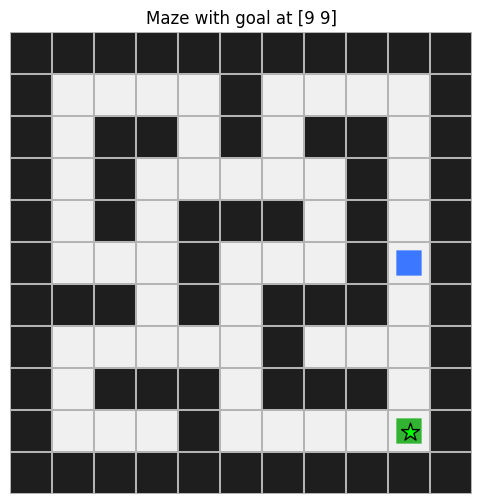

In [2]:
MAZE_LAYOUT = [
    [1,1,1,1,1,1,1,1,1,1,1],
    [1,0,0,0,0,1,0,0,0,0,1],
    [1,0,1,1,0,1,0,1,1,0,1],
    [1,0,1,0,0,0,0,0,1,0,1],
    [1,0,1,0,1,1,1,0,1,0,1],
    [1,0,0,0,1,0,0,0,1,0,1],
    [1,1,1,0,1,0,1,1,1,0,1],
    [1,0,0,0,0,0,1,0,0,0,1],
    [1,0,1,1,1,0,1,1,1,0,1],
    [1,0,0,0,1,0,0,0,0,0,1],
    [1,1,1,1,1,1,1,1,1,1,1],
]

def make_env(goal=(9, 9), slip_prob=0.00, max_horizon=100):
    base = MazeGridWorld(
        maze=MAZE_LAYOUT,
        max_episode_steps=max_horizon,
    )
    env = MazeGoalWrapper(
        base,
        goal_position=goal,
        goal_reward=1.0,
        step_reward=0.0,
        slip_prob=slip_prob,
        reward_mode="simple",
    )
    return env

env = make_env(goal=(9, 9))
obs, info = env.reset()

img = env.unwrapped.render()
goal = env.goal_position

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.scatter(
    goal[0] * 40 + 20,
    goal[1] * 40 + 20,
    c="lime",
    s=180,
    marker="*",
    edgecolors="black",
)
plt.title(f"Maze with goal at {goal}")
plt.axis("off")
plt.show()

In [3]:

class FactorisedDQN_QNetwork_MLPRawGoal(nn.Module):
    def __init__(
        self,
        obs_dim: int,
        num_actions: int,
        goal_dim: int = 2,
        hidden_dim: int = 128,
        rep_dim: int = 64,
        q_hidden_dim: int = 128,
        normalize_embeddings: bool = True,
    ):
        super().__init__()
        self.obs_dim = obs_dim
        self.num_actions = num_actions
        self.action_dim = num_actions 
        self.goal_dim = goal_dim
        self.hidden_dim = hidden_dim
        self.rep_dim = rep_dim
        self.q_hidden_dim = q_hidden_dim
        self.normalize_embeddings = normalize_embeddings

        # Shared SA encoder φ(s,a)
        self.sa_encoder = nn.Sequential(
            nn.Linear(obs_dim + num_actions, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, rep_dim),
        )

        # Goal-conditioned MLP head f([φ, g])
        # We'll treat the activation after the first Linear+ReLU as the "task code".
        self.q_head = nn.Sequential(
            nn.Linear(rep_dim + goal_dim, q_hidden_dim),
            nn.ReLU(),
            nn.Linear(q_hidden_dim, q_hidden_dim),
            nn.ReLU(),
            nn.Linear(q_hidden_dim, 1),
        )

    # -------- Embeddings --------
    def encode_state_action(self, obs: torch.Tensor, act_onehot: torch.Tensor) -> torch.Tensor:
        """
        obs: [B, obs_dim]
        act_onehot: [B, num_actions]
        returns: φ(s,a) in [B, rep_dim]
        """
        x = torch.cat([obs, act_onehot], dim=-1)
        z = self.sa_encoder(x)
        if self.normalize_embeddings:
            z = F.normalize(z, dim=-1)
        return z

    # -------- Q from embeddings --------
    def q_from_embeddings(self, phi: torch.Tensor, goal_raw: torch.Tensor) -> torch.Tensor:
        """
        phi: [N, rep_dim]
        goal_raw: [N, goal_dim]
        returns: [N, 1]
        """
        x = torch.cat([phi, goal_raw], dim=-1)
        return self.q_head(x)

    # -------- Full Q over actions --------
    def q_values_from_state_goal(self, obs: torch.Tensor, goal_raw: torch.Tensor) -> torch.Tensor:
        """
        obs: [B, obs_dim]
        goal_raw: [B, goal_dim]
        returns: [B, num_actions] Q-values for each action.
        """
        B = obs.shape[0]
        device = obs.device

        # One-hot actions and repeated obs
        act_eye = torch.eye(self.num_actions, device=device).unsqueeze(0).expand(B, -1, -1)
        obs_rep = obs.unsqueeze(1).expand(-1, self.num_actions, -1)

        obs_flat = obs_rep.reshape(B * self.num_actions, self.obs_dim)
        act_flat = act_eye.reshape(B * self.num_actions, self.num_actions)
        phi_flat = self.encode_state_action(obs_flat, act_flat)  # [B*A, rep_dim]

        goal_rep = goal_raw.unsqueeze(1).expand(-1, self.num_actions, -1)
        goal_flat = goal_rep.reshape(B * self.num_actions, self.goal_dim)

        q_flat = self.q_from_embeddings(phi_flat, goal_flat)  # [B*A, 1]
        q_vals = q_flat.view(B, self.num_actions)
        return q_vals

    def q_val_for_argmax_action(self, obs: torch.Tensor, goal_raw: torch.Tensor) -> torch.Tensor:
        """
        Convenience wrapper: same as q_values_from_state_goal, used for greedy action selection.
        """
        return self.q_values_from_state_goal(obs, goal_raw)
    
    def encode_goal(self, goal_raw: torch.Tensor, phi_probe: torch.Tensor = None) -> torch.Tensor:
        """
        Returns an MLP-derived task code for the goal.
        goal_raw: [B, goal_dim]
        phi_probe: optional [B, rep_dim] or [rep_dim]
        output: [B, q_hidden_dim]
        """
        if phi_probe is None:
            phi_probe = torch.zeros(goal_raw.shape[0], self.rep_dim, device=goal_raw.device, dtype=goal_raw.dtype)
        elif phi_probe.ndim == 1:
            phi_probe = phi_probe.unsqueeze(0).expand(goal_raw.shape[0], -1)

        x = torch.cat([phi_probe, goal_raw], dim=-1)
        h1 = self.q_head[0](x)
        h1 = F.relu(h1)

        if self.normalize_embeddings:
            h1 = F.normalize(h1, dim=-1)
        return h1
    
class NextStateEncoder(nn.Module):
    def __init__(self, obs_dim: int, hidden_dim: int = 128, rep_dim: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, rep_dim),
        )

    def forward(self, next_obs: torch.Tensor) -> torch.Tensor:
        z = self.net(next_obs)
        z = F.normalize(z, dim=-1)
        return z
    

def extract_task_code_from_mlp(
    q_network: FactorisedDQN_QNetwork_MLPRawGoal,
    goal_raw,
    device,
    phi_probe: torch.Tensor = None,
):
    q_network.eval()
    with torch.no_grad():
        if phi_probe is None:
            phi_probe = torch.zeros(q_network.rep_dim, device=device)
        if phi_probe.ndim == 1:
            phi_probe = phi_probe.unsqueeze(0)

        goal_t = torch.tensor(goal_raw, dtype=torch.float32, device=device).unsqueeze(0)
        x = torch.cat([phi_probe, goal_t], dim=-1)

        h1 = q_network.q_head[0](x)
        h1 = F.relu(h1)

    return h1.squeeze(0).cpu().numpy()

In [4]:
def dqn_train_mlp_raw_goal_online(
    seed: int = 42,
    q_network=None,
    q_target_network=None,
    env=None,
    buffer_capacity=None,
    obs_dim=None,
    device=None,
    total_steps=100000,
    warmup_steps=5000,
    batch_size=256,
    gamma=0.99,
    tau=0.005,
    eps_start=1.0,
    eps_end=0.05,
    eps_decay_steps=80000,
    train_freq=4,
    goal=None,
    td_steps=1,
    make_env=None,
    epsilon_reduction=False,
    eps_start_transfer=0.2,
    eps_end_transfer=0.05,
    eps_decay_steps_transfer=20000,
    lr_sa=1e-3,
    lr_ns=1e-3,
    lr_td=1e-3,
    next_state_encoder=None,
    temperature=0.05,
    contrastive_reg_coef=0.0,
    sigreg_coef=0.0,
    dyn_coef=1.0,
    freeze_sa_encoder=False,
    td_updates_sa_encoder=False,
    early_stop_reward=0.99,
    early_stop_patience=5,
    enable_early_stop=True,
):
    if q_network is None:
        raise ValueError("q_network must be provided")
    if q_target_network is None:
        raise ValueError("q_target_network must be provided")
    if env is None:
        raise ValueError("env must be provided")
    if buffer_capacity is None:
        raise ValueError("buffer_capacity must be provided")
    if goal is None:
        raise ValueError("goal must be provided")
    if make_env is None:
        raise ValueError("make_env must be provided")

    if device is None:
        device = next(q_network.parameters()).device

    if obs_dim is None:
        obs_dim = int(env.observation_space.shape[0])

    set_seed(seed)
    num_actions = env.action_space.n

    if not freeze_sa_encoder:
        if next_state_encoder is None:
            raise ValueError("next_state_encoder must be provided when freeze_sa_encoder=False")

        for p in q_network.sa_encoder.parameters():
            p.requires_grad_(True)
        for p in q_target_network.sa_encoder.parameters():
            p.requires_grad_(True)

        opt_dyn = optim.Adam([
            {"params": q_network.sa_encoder.parameters(), "lr": lr_sa},
            {"params": next_state_encoder.parameters(), "lr": lr_ns},
        ])
    else:
        for p in q_network.sa_encoder.parameters():
            p.requires_grad_(False)
        for p in q_target_network.sa_encoder.parameters():
            p.requires_grad_(False)
        opt_dyn = None

    if td_updates_sa_encoder and not freeze_sa_encoder:
        opt_td = optim.Adam([
            {"params": q_network.sa_encoder.parameters(), "lr": lr_td},
            {"params": q_network.q_head.parameters(), "lr": lr_td},
        ])
    else:
        opt_td = optim.Adam([
            {"params": q_network.q_head.parameters(), "lr": lr_td},
        ])

    buffer = TrajectoryReplayBufferDiscrete(buffer_capacity, obs_dim, 1, device=device)

    goal_arr = np.array(goal, dtype=np.float32)
    goal_t_single = torch.tensor(goal_arr, dtype=torch.float32, device=device).unsqueeze(0)

    obs, _ = env.reset()
    global_step = 0
    eval_returns = []
    eval_returns_time = []
    start_time = time.perf_counter()
    min_steps = None
    min_time = None
    success_streak = 0

    contrastive_loss_val = torch.tensor(0.0, device=device)
    sigreg_loss_val = torch.tensor(0.0, device=device)
    dyn_total_loss = torch.tensor(0.0, device=device)
    td_loss = torch.tensor(0.0, device=device)
    all_logits = None

    q_network.train()
    q_target_network.train()
    if next_state_encoder is not None:
        next_state_encoder.train()

    while global_step < total_steps:
        if epsilon_reduction:
            frac = min(1.0, global_step / eps_decay_steps_transfer)
            eps = eps_start_transfer + frac * (eps_end_transfer - eps_start_transfer)
        else:
            frac = min(1.0, global_step / eps_decay_steps)
            eps = eps_start + frac * (eps_end - eps_start)

        if np.random.random() < eps:
            action = env.action_space.sample()
        else:
            obs_t_single = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
            with torch.no_grad():
                q_vals = q_network.q_val_for_argmax_action(obs_t_single, goal_t_single)
                action = int(q_vals.argmax(dim=-1).item())

        next_obs, rew, term, trunc, _ = env.step(action)
        done = term or trunc

        buffer.add_transition(obs, action, rew, next_obs, done)
        obs = next_obs
        global_step += 1

        if done:
            obs, _ = env.reset()

        if len(buffer) >= warmup_steps and global_step % train_freq == 0:
            batch = buffer.sample(batch_size)

            obs_t = batch.obs
            act_t = batch.actions.long()
            rew_t = batch.rewards
            next_obs_t = batch.next_obs
            term_t = batch.terminated.float()
            trunc_t = batch.truncated.float()

            done_t = torch.clamp(term_t + trunc_t, 0.0, 1.0)
            if done_t.ndim == 1:
                done_t = done_t.unsqueeze(-1)
            if rew_t.ndim == 1:
                rew_t = rew_t.unsqueeze(-1)

            B = obs_t.shape[0]
            goal_batch = goal_t_single.expand(B, -1)

            act_onehot = F.one_hot(
                act_t.squeeze(-1),
                num_classes=num_actions
            ).float()

            # 1) DYNAMICS UPDATE
            if not freeze_sa_encoder:
                z_sa = q_network.encode_state_action(obs_t, act_onehot)
                z_s_prime = next_state_encoder(next_obs_t)

                all_logits = z_sa @ z_s_prime.T

                contrastive_loss_val = contrastive_loss(
                    all_logits,
                    temperature=temperature,
                    reg_coef=contrastive_reg_coef,
                )

                if sigreg_coef > 0.0:
                    sigreg_loss_val = sigreg_loss(z_sa)
                else:
                    sigreg_loss_val = torch.tensor(0.0, device=device)

                dyn_total_loss = dyn_coef * contrastive_loss_val + sigreg_coef * sigreg_loss_val

                opt_dyn.zero_grad(set_to_none=True)
                dyn_total_loss.backward()
                nn.utils.clip_grad_norm_(q_network.sa_encoder.parameters(), 10.0)
                nn.utils.clip_grad_norm_(next_state_encoder.parameters(), 10.0)
                opt_dyn.step()
            else:
                contrastive_loss_val = torch.tensor(0.0, device=device)
                sigreg_loss_val = torch.tensor(0.0, device=device)
                dyn_total_loss = torch.tensor(0.0, device=device)

            # 2) TD UPDATE
            if td_updates_sa_encoder and not freeze_sa_encoder:
                phi_td = q_network.encode_state_action(obs_t, act_onehot)
            else:
                with torch.no_grad():
                    phi_td = q_network.encode_state_action(obs_t, act_onehot)

            current_q = q_network.q_from_embeddings(phi_td, goal_batch)

            with torch.no_grad():
                next_q_vals = q_target_network.q_val_for_argmax_action(next_obs_t, goal_batch)
                next_q = next_q_vals.max(dim=-1, keepdim=True).values
                gamma_final = gamma ** td_steps
                target = rew_t + gamma_final * (1.0 - done_t) * next_q

            td_loss = F.mse_loss(current_q, target)

            opt_td.zero_grad(set_to_none=True)
            td_loss.backward()

            if td_updates_sa_encoder and not freeze_sa_encoder:
                nn.utils.clip_grad_norm_(q_network.sa_encoder.parameters(), 10.0)
            nn.utils.clip_grad_norm_(q_network.q_head.parameters(), 10.0)

            opt_td.step()

            # 3) TARGET UPDATE
            with torch.no_grad():
                for p, p_tgt in zip(q_network.parameters(), q_target_network.parameters()):
                    p_tgt.data.mul_(1.0 - tau).add_(tau * p.data)

        if global_step % 1000 == 0:
            eval_env = make_env(goal)
            goal_eval_t = torch.tensor(
                np.array(goal, dtype=np.float32),
                dtype=torch.float32,
                device=device
            ).unsqueeze(0)

            def eval_policy(o):
                o_t = torch.tensor(o, dtype=torch.float32, device=device).unsqueeze(0)
                with torch.no_grad():
                    q_vals = q_network.q_val_for_argmax_action(o_t, goal_eval_t)
                    return int(q_vals.argmax(dim=-1).item())

            mean_ret, mean_len = evaluate_policy(eval_env, eval_policy, episodes=8)
            eval_returns.append((global_step, mean_ret))

            if all_logits is not None:
                with torch.no_grad():
                    diag_logits = all_logits.diag().mean().item()
                    offdiag_logits = (
                        (all_logits.sum() - all_logits.diag().sum()) /
                        (all_logits.numel() - all_logits.shape[0])
                    ).item()
            else:
                diag_logits = 0.0
                offdiag_logits = 0.0

            print(
                f"[DQN-mlp-raw-goal] step={global_step:7d} | eps={eps:.3f} "
                f"| eval_return={mean_ret:.3f} | eval_len={mean_len:.1f} "
                f"| TD={td_loss.item():.4f} "
                f"| Contrastive={contrastive_loss_val.item():.4f} "
                f"| DynTotal={dyn_total_loss.item():.4f} "
                f"| diag={diag_logits:.4f} | offdiag={offdiag_logits:.4f} "
                f"| SigReg={sigreg_loss_val.item():.4f} "
                f"| freeze_sa={freeze_sa_encoder} | td_updates_sa={td_updates_sa_encoder}"
            )

            if mean_ret >= early_stop_reward:
                success_streak += 1
            else:
                success_streak = 0

            if enable_early_stop and success_streak >= early_stop_patience:
                min_steps = global_step
                min_time = time.perf_counter() - start_time
                print(f"Good policy achieved at step {global_step} with mean return {mean_ret:.3f}")
                print(
                    f"Early stopping triggered at step {global_step} "
                    f"after {success_streak} consecutive evals with "
                    f"mean return >= {early_stop_reward:.2f}"
                )
                eval_env.close()
                break

            eval_env.close()

    task_code = extract_task_code_from_mlp(
        q_network=q_network,
        goal_raw=goal_arr,
        device=device,
        phi_probe=None,
    )

    obs_probe_np = np.array([5.0, 5.0], dtype=np.float32)

    base_env = env.unwrapped if hasattr(env, "unwrapped") else env
    env_action_names = getattr(base_env, "action_names", ["Up", "Down", "Left", "Right"])
    act_probe_idx = env_action_names.index("Up")

    sa_embedding_mean = extract_mean_sa_embedding(
        q_network=q_network,
        buffer=buffer,
        num_actions=num_actions,
        batch_size=256,
        device=device,
        as_numpy=True,
    )

    sa_embedding_fixed = extract_fixed_probe_sa_embedding(
        q_network=q_network,
        obs_probe=obs_probe_np,
        act_probe_idx=act_probe_idx,
        num_actions=num_actions,
        device=device,
        as_numpy=True,
    )

    sa_batch_final = extract_sa_batch_for_isotropy(
        q_network=q_network,
        buffer=buffer,
        num_actions=num_actions,
        batch_size=1024,
        device=device,
        as_numpy=True,
    )

    env.close()
    return (
        q_network,
        q_target_network,
        next_state_encoder,
        eval_returns,
        min_steps,
        min_time,
        task_code,
        sa_embedding_mean,
        sa_embedding_fixed,
        sa_batch_final,
        buffer,
    )

## Training Loop across goals and seeds


================ SEED 42 ================


----- seed=42, goal=(9, 9) -----

[DQN-mlp-raw-goal] step=   1000 | eps=0.988 | eval_return=-9.912 | eval_len=100.0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=False | td_updates_sa=False
[DQN-mlp-raw-goal] step=   2000 | eps=0.976 | eval_return=-8.600 | eval_len=87.6 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=False | td_updates_sa=False
[DQN-mlp-raw-goal] step=   3000 | eps=0.964 | eval_return=-9.900 | eval_len=100.0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=False | td_updates_sa=False
[DQN-mlp-raw-goal] step=   4000 | eps=0.953 | eval_return=-8.587 | eval_len=87.6 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=False | td_updates_sa=False
[DQN-mlp-raw-goal] step=   5000 | eps=0.941

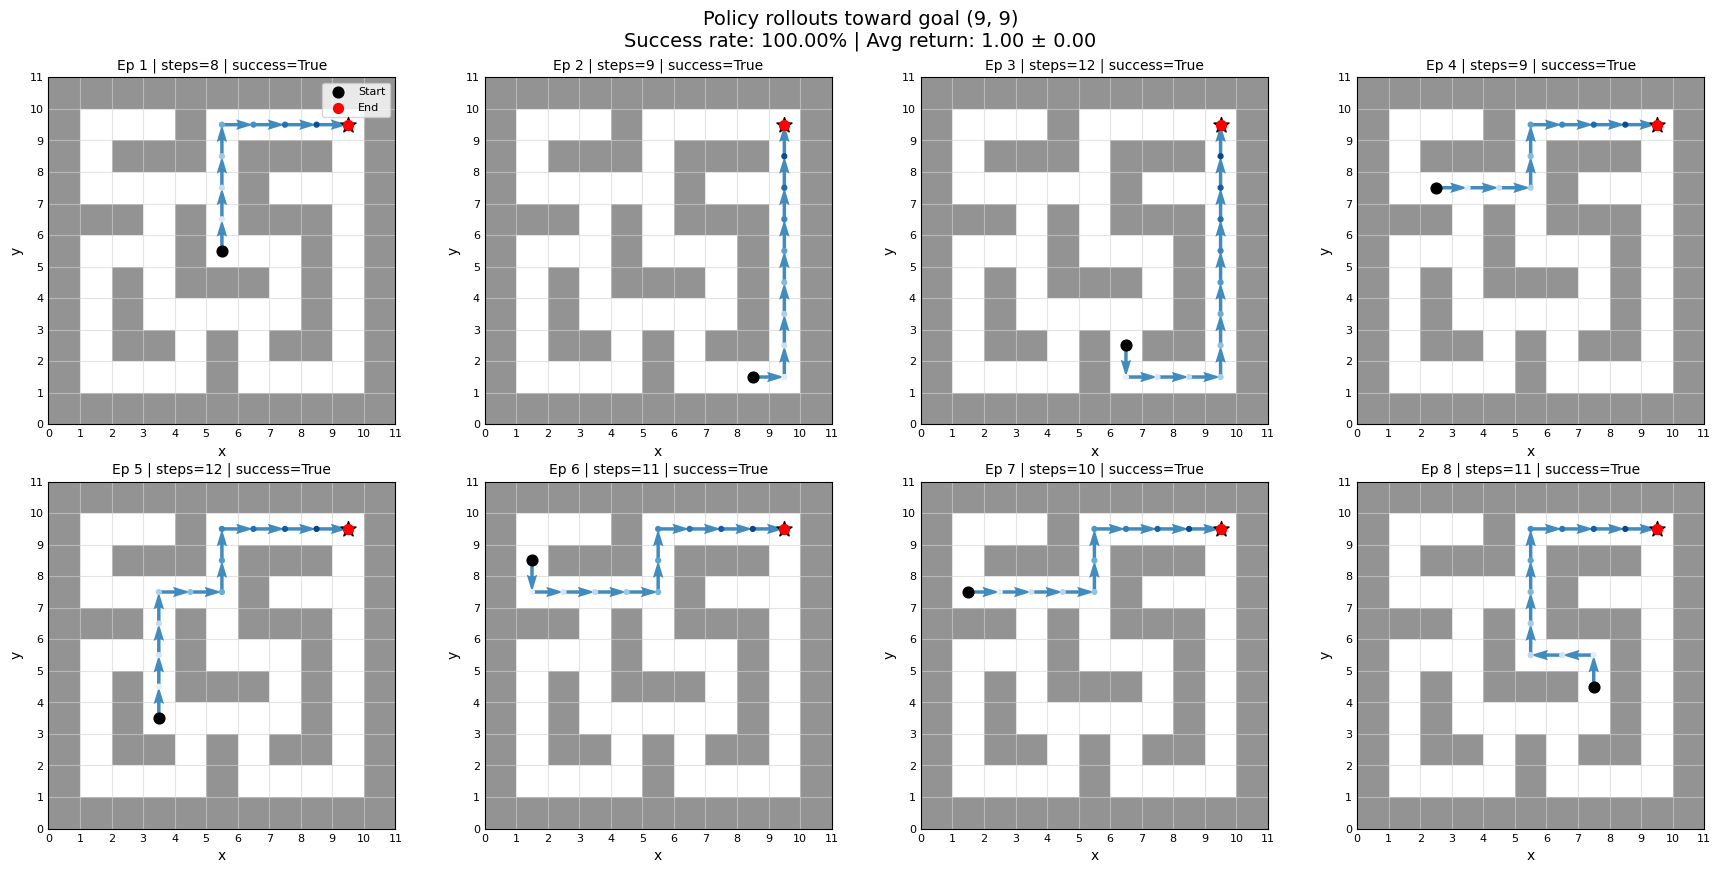

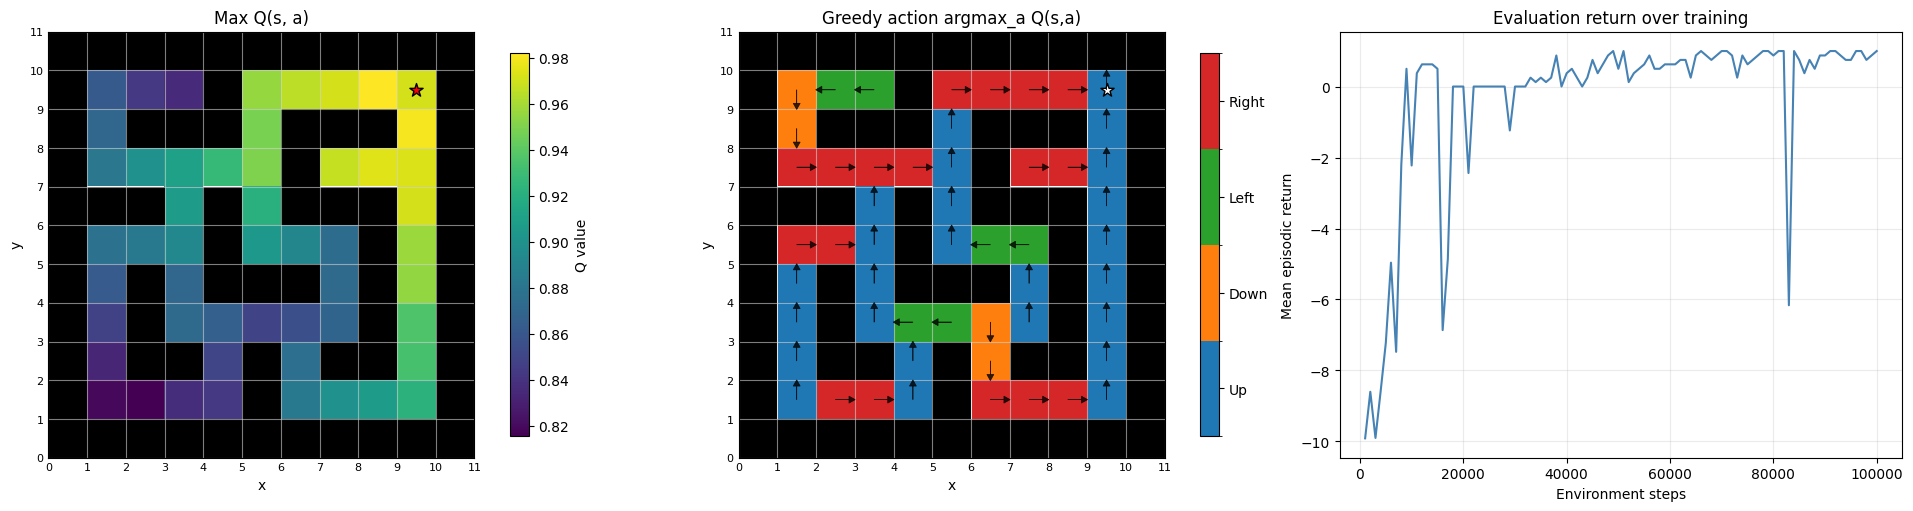

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 128)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [5.82308   5.090625  4.9619603 4.413599  4.2559824]
cumulative variance (first 5 dims): [0.16380244 0.28898883 0.40792704 0.5020294  0.5895307 ]
Skipping cosine histogram: phi dim = 64, goal/task dim = 128


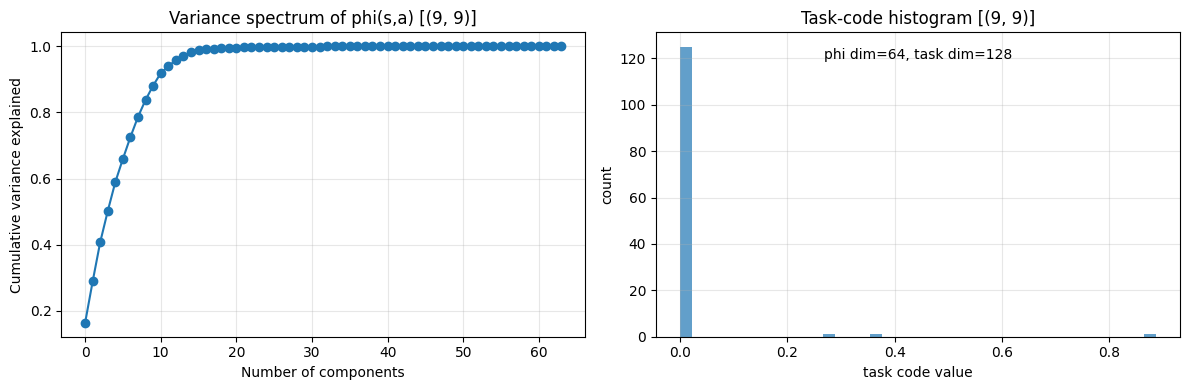


Goal embedding cosine similarity matrix:
     (9, 9)
  (9, 9)      1.000

----- seed=42, goal=(1, 1) -----

[DQN-mlp-raw-goal] step=   1000 | eps=0.988 | eval_return=-4.975 | eval_len=100.0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=False | td_updates_sa=False
[DQN-mlp-raw-goal] step=   2000 | eps=0.976 | eval_return=-3.675 | eval_len=100.0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=False | td_updates_sa=False
[DQN-mlp-raw-goal] step=   3000 | eps=0.964 | eval_return=-7.462 | eval_len=100.0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=False | td_updates_sa=False
[DQN-mlp-raw-goal] step=   4000 | eps=0.953 | eval_return=-6.225 | eval_len=100.0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=False | td_updates_sa=False
[DQN-mlp-ra

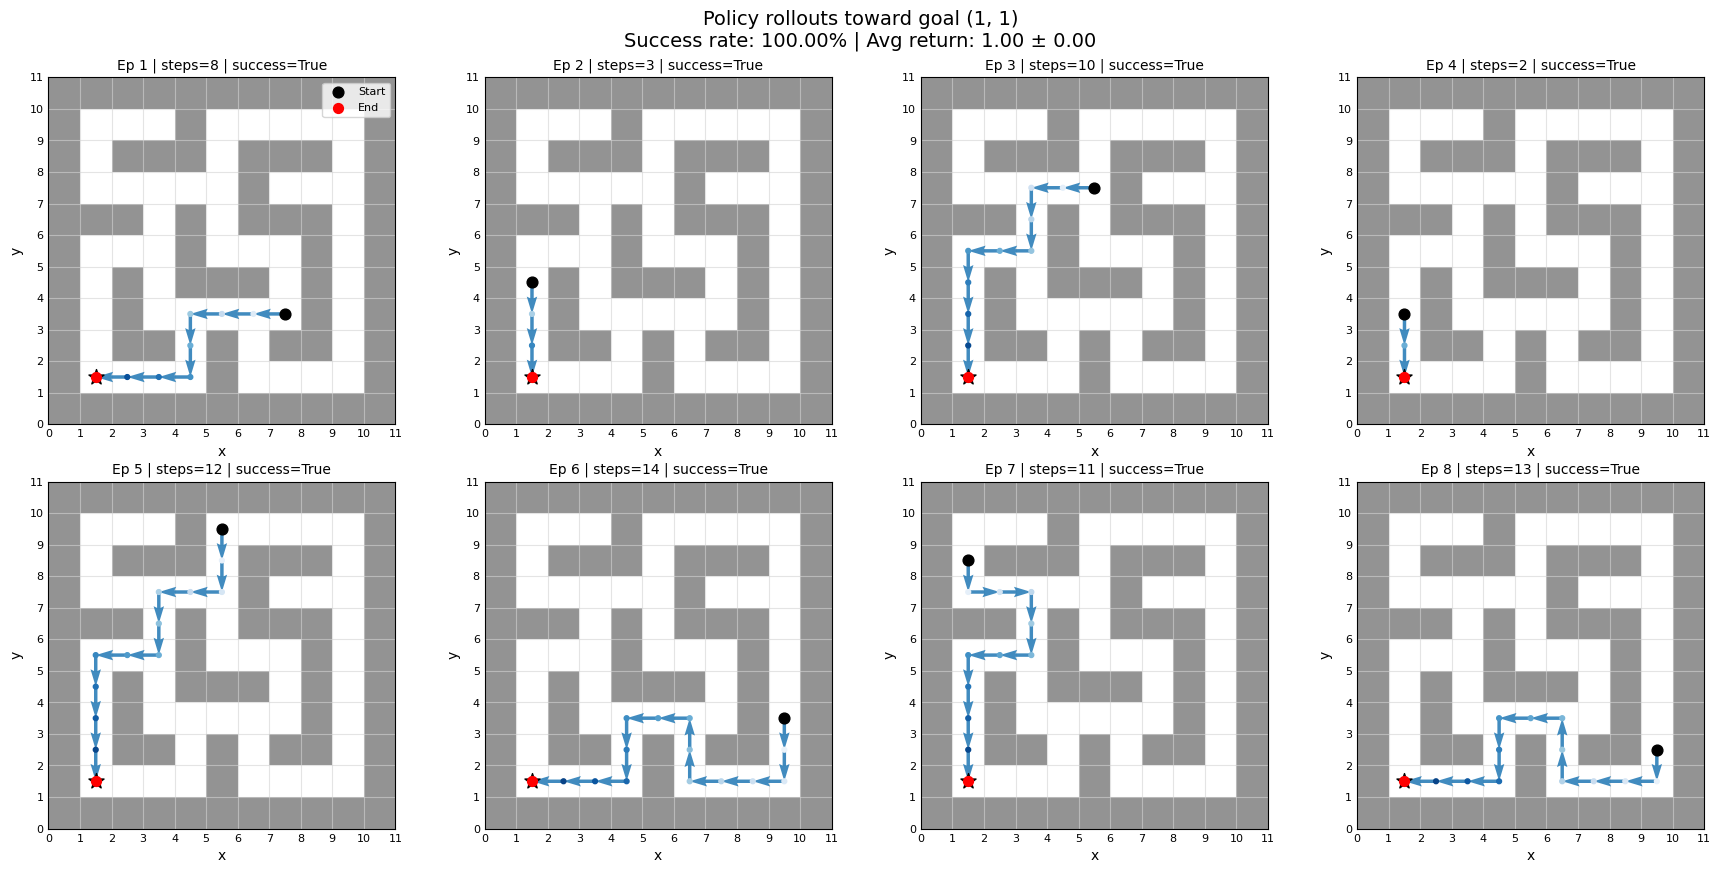

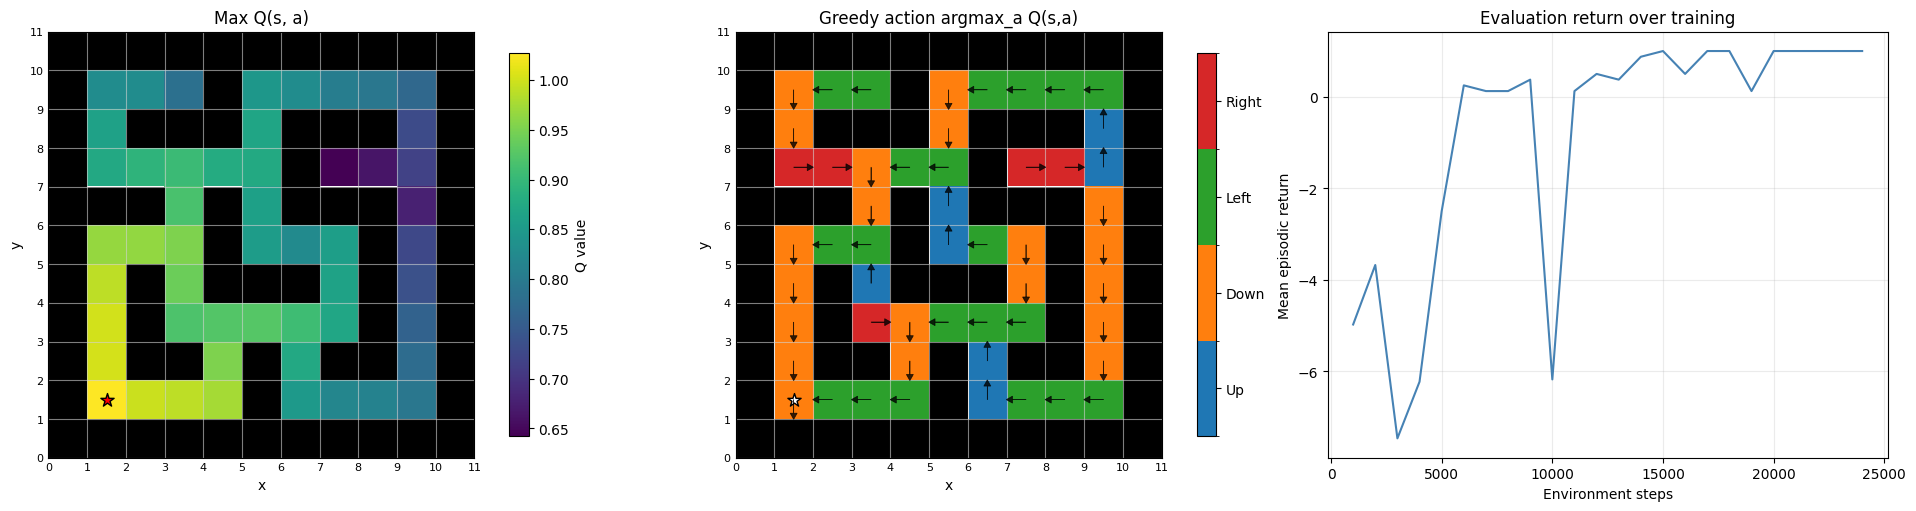

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 128)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [5.255374  4.906619  4.797031  4.452     4.1204357]
cumulative variance (first 5 dims): [0.13307731 0.24907823 0.3599553  0.45545614 0.5372617 ]
Skipping cosine histogram: phi dim = 64, goal/task dim = 128


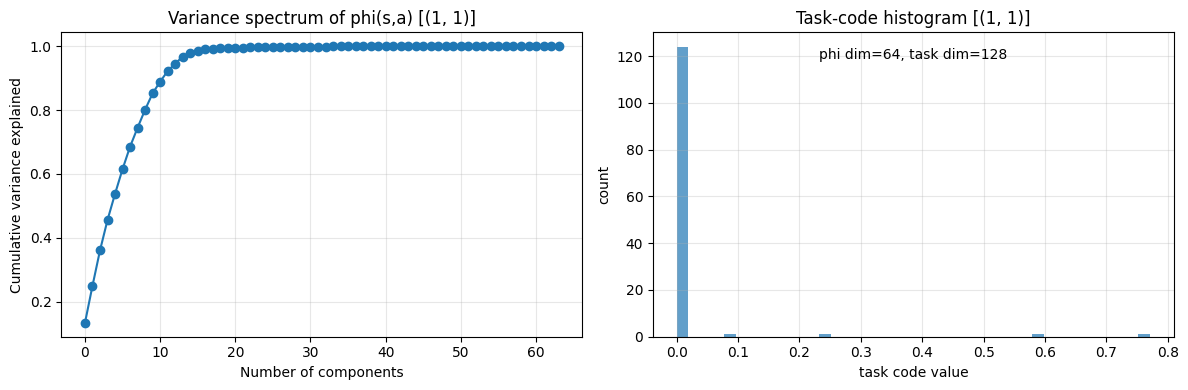


Goal embedding cosine similarity matrix:
     (9, 9)     (1, 1)
  (9, 9)      1.000      0.896
  (1, 1)      0.896      1.000

Off-diagonal mean similarity: 0.896
Off-diagonal min similarity: 0.896
Off-diagonal max similarity: 0.896

----- seed=42, goal=(7, 7) -----

[DQN-mlp-raw-goal] step=   1000 | eps=0.988 | eval_return=-4.937 | eval_len=100.0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=False | td_updates_sa=False
[DQN-mlp-raw-goal] step=   2000 | eps=0.976 | eval_return=-3.725 | eval_len=100.0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=False | td_updates_sa=False
[DQN-mlp-raw-goal] step=   3000 | eps=0.964 | eval_return=-7.412 | eval_len=100.0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=False | td_updates_sa=False
[DQN-mlp-raw-goal] step=   4000 | eps=0.953 | eval_return=-4.925 | eval

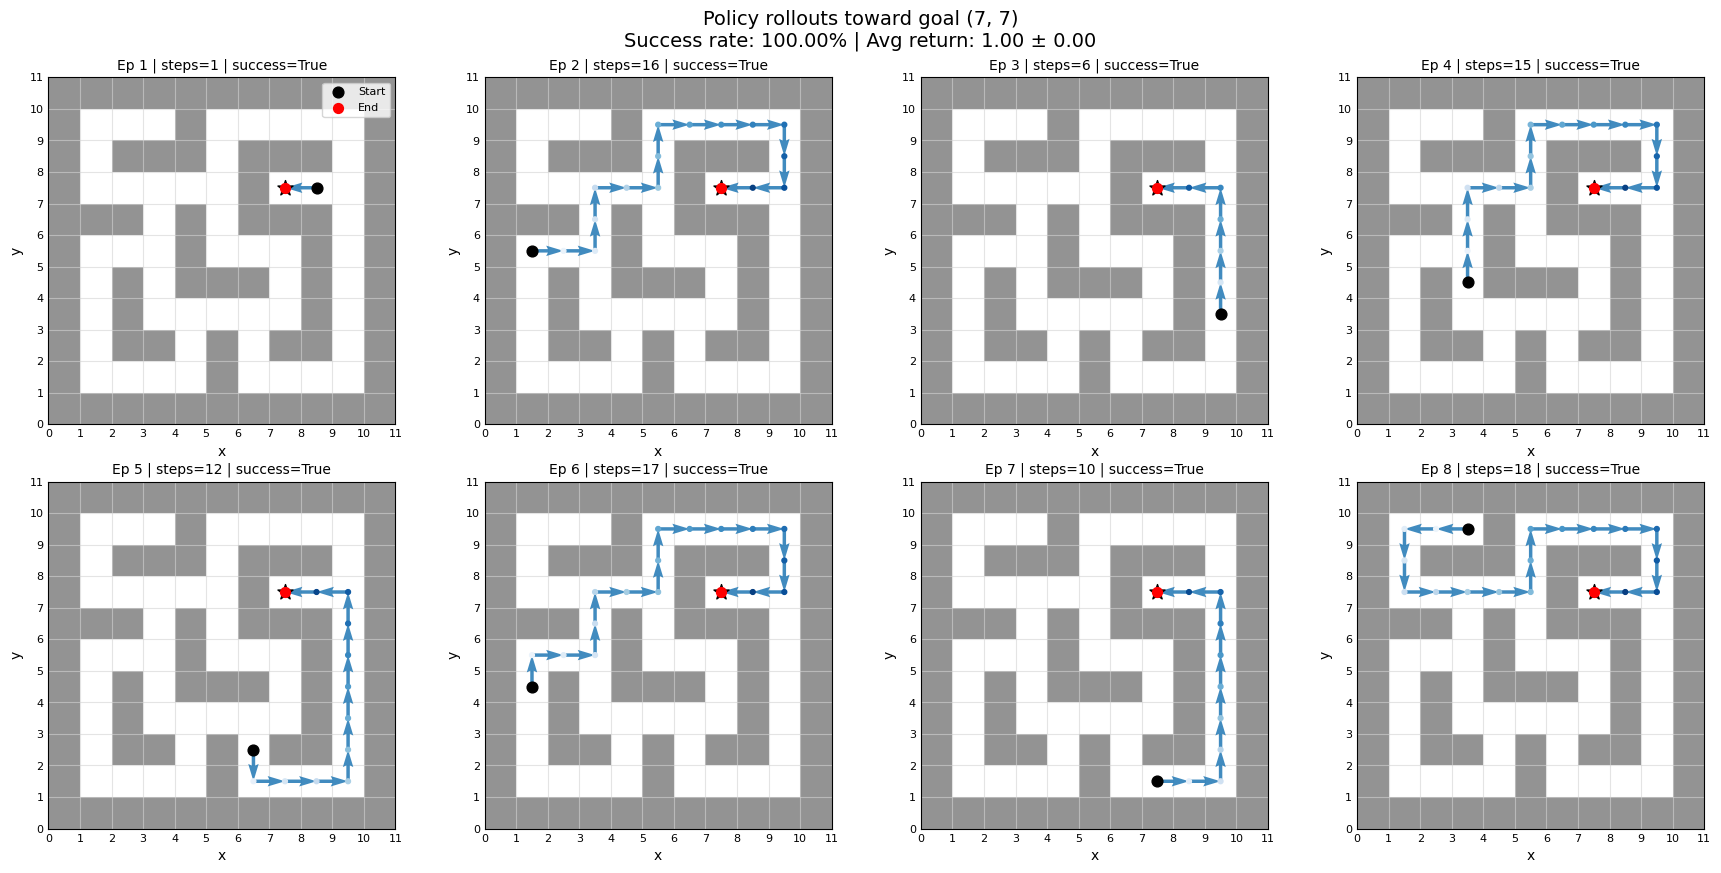

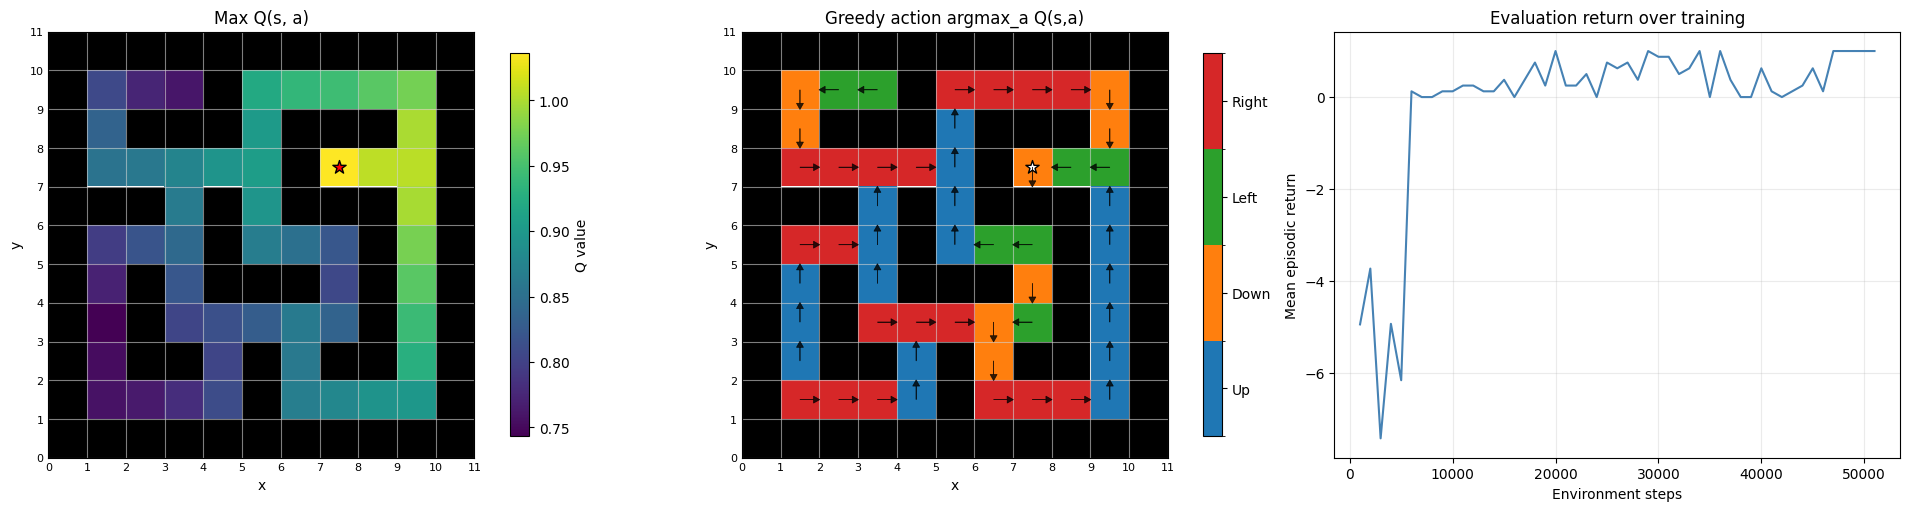

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 128)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [4.7944508 4.645432  4.257527  4.0920124 3.868043 ]
cumulative variance (first 5 dims): [0.11088953 0.21499297 0.3024365  0.3832133  0.45538974]
Skipping cosine histogram: phi dim = 64, goal/task dim = 128


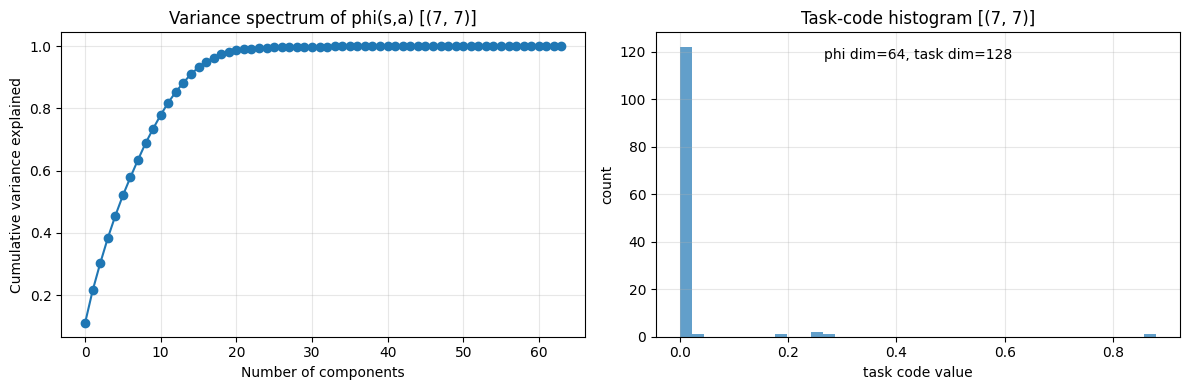


Goal embedding cosine similarity matrix:
     (9, 9)     (1, 1)     (7, 7)
  (9, 9)      1.000      0.896      0.889
  (1, 1)      0.896      1.000      0.850
  (7, 7)      0.889      0.850      1.000

Off-diagonal mean similarity: 0.878
Off-diagonal min similarity: 0.850
Off-diagonal max similarity: 0.896

----- seed=42, goal=(3, 5) -----

[DQN-mlp-raw-goal] step=   1000 | eps=0.988 | eval_return=-9.850 | eval_len=100.0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=False | td_updates_sa=False
[DQN-mlp-raw-goal] step=   2000 | eps=0.976 | eval_return=-8.600 | eval_len=100.0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=False | td_updates_sa=False
[DQN-mlp-raw-goal] step=   3000 | eps=0.964 | eval_return=-6.100 | eval_len=87.6 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=False | td_updates_sa=Fal

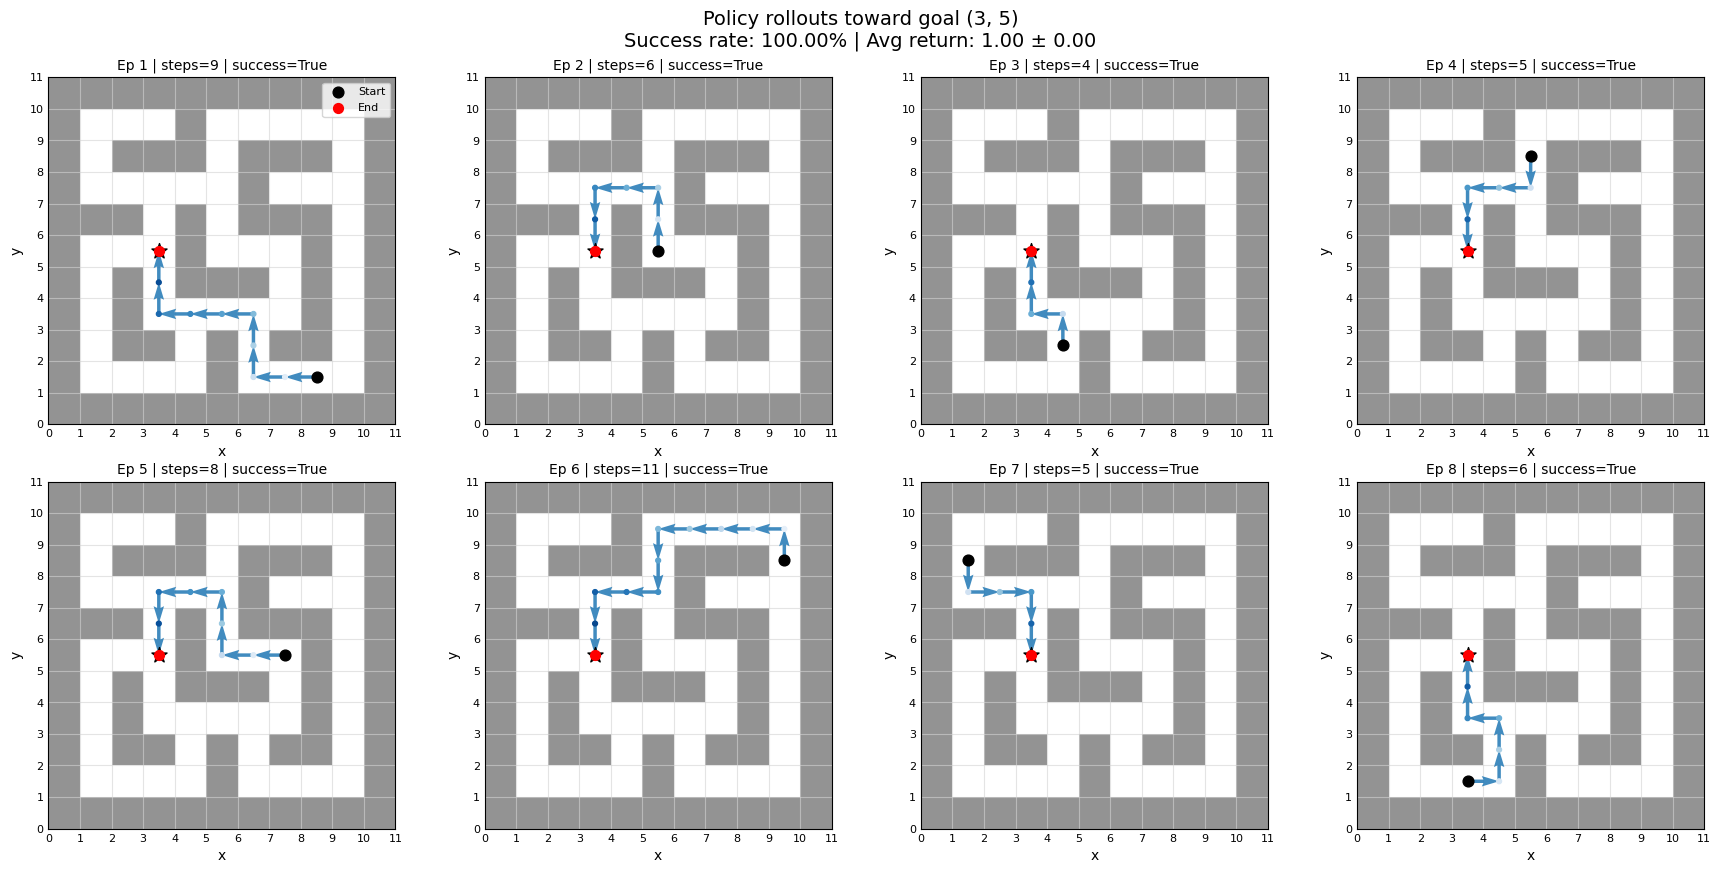

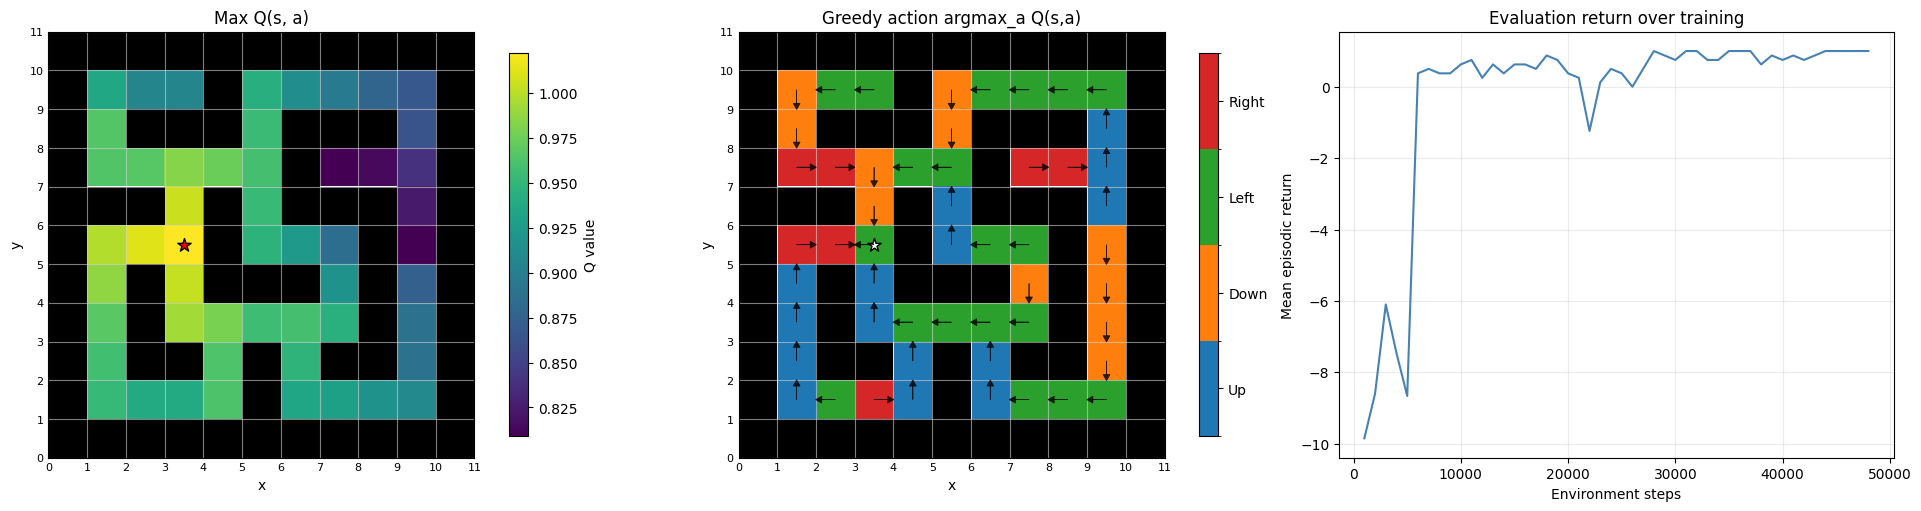

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 128)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [4.504842  4.3399057 4.0815635 3.9602842 3.8046114]
cumulative variance (first 5 dims): [0.09792693 0.18881431 0.26920322 0.34488577 0.41473532]
Skipping cosine histogram: phi dim = 64, goal/task dim = 128


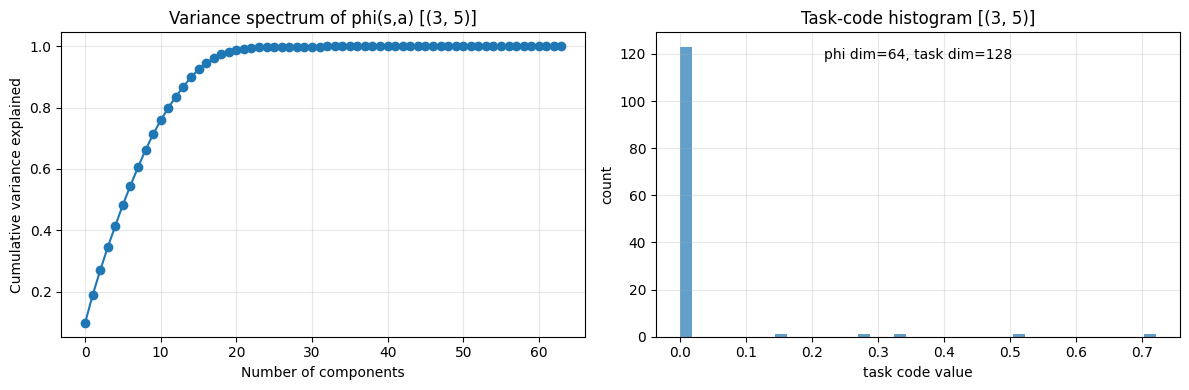


Goal embedding cosine similarity matrix:
     (9, 9)     (1, 1)     (7, 7)     (3, 5)
  (9, 9)      1.000      0.896      0.889      0.292
  (1, 1)      0.896      1.000      0.850      0.287
  (7, 7)      0.889      0.850      1.000      0.382
  (3, 5)      0.292      0.287      0.382      1.000

Off-diagonal mean similarity: 0.599
Off-diagonal min similarity: 0.287
Off-diagonal max similarity: 0.896

----- seed=42, goal=(3, 9) -----

[DQN-mlp-raw-goal] step=   1000 | eps=0.988 | eval_return=-6.062 | eval_len=87.6 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=False | td_updates_sa=False
[DQN-mlp-raw-goal] step=   2000 | eps=0.976 | eval_return=-4.937 | eval_len=100.0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=False | td_updates_sa=False
[DQN-mlp-raw-goal] step=   3000 | eps=0.964 | eval_return=-3.737 | eval_len=100.0 | TD=0.0000 | Contrastive=0.0000 | Dyn

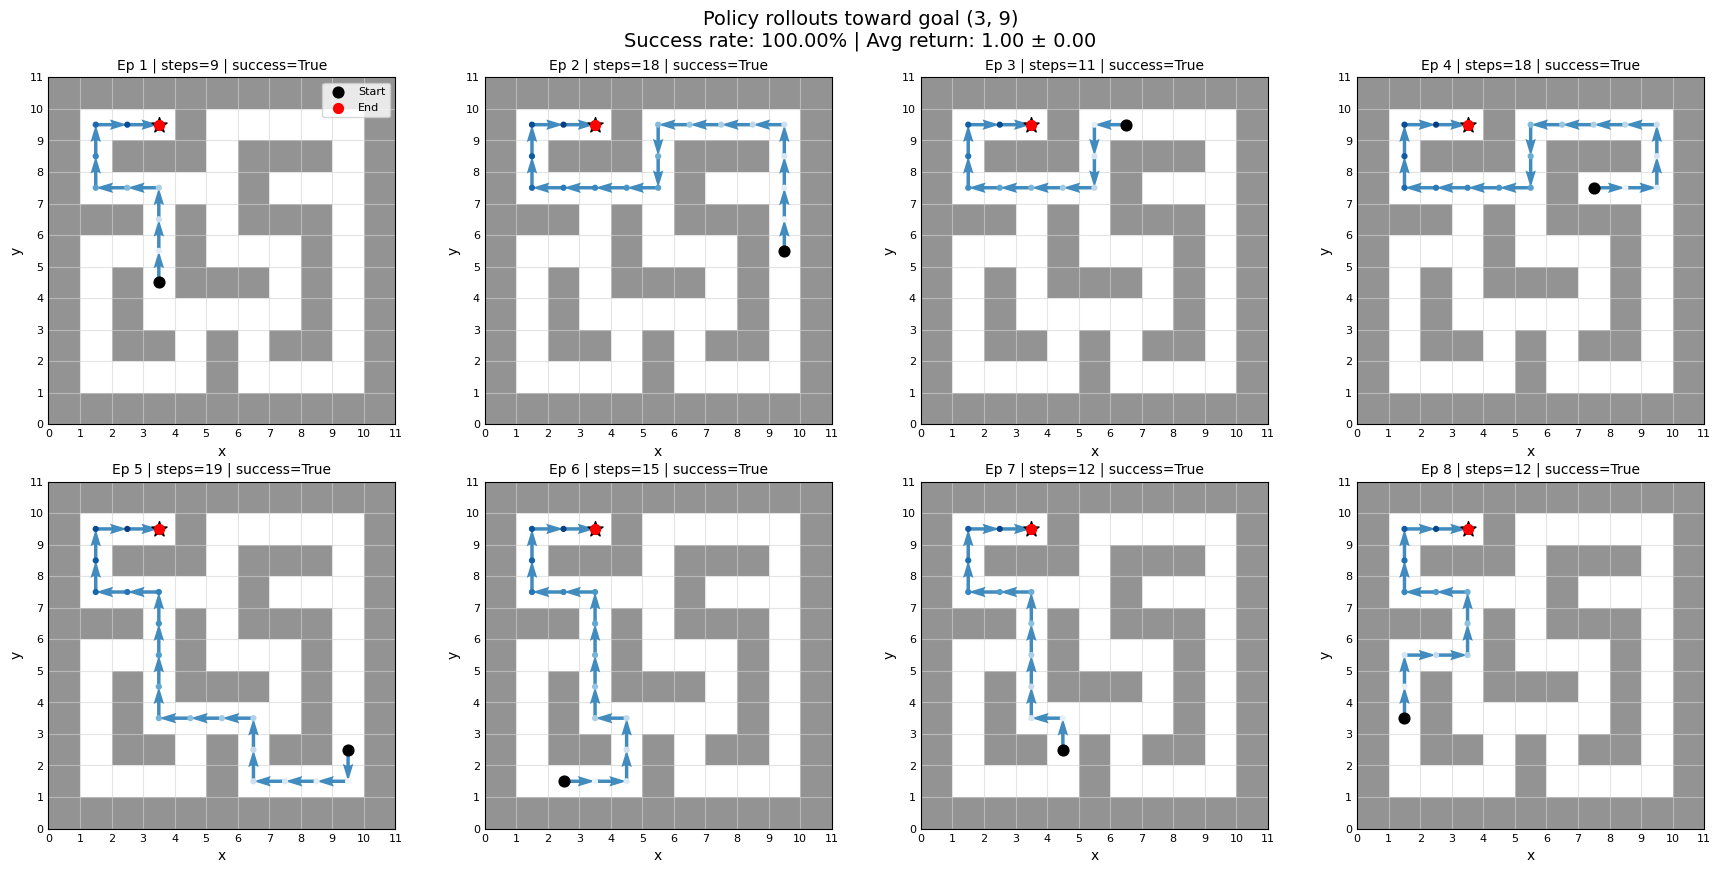

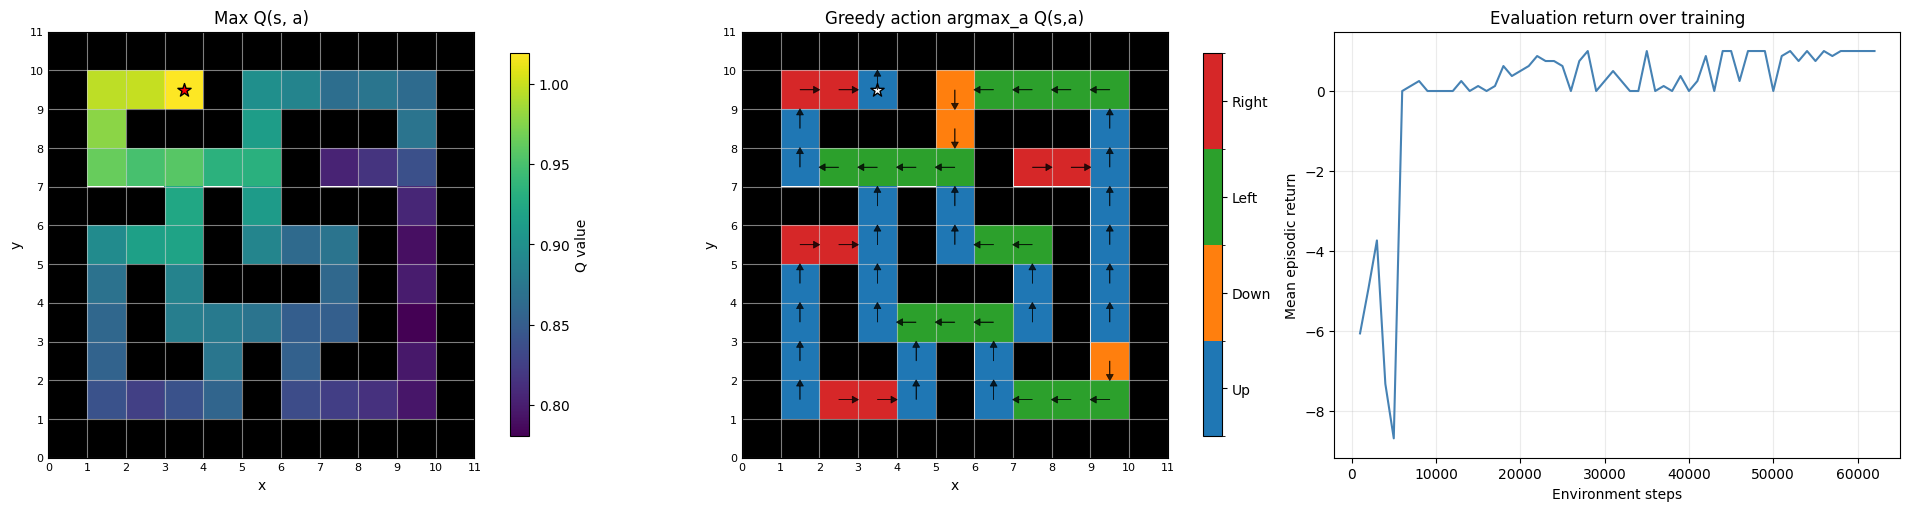

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 128)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [4.253937  4.182331  3.8919883 3.8184662 3.552883 ]
cumulative variance (first 5 dims): [0.08740669 0.17189553 0.24506092 0.31548813 0.37645927]
Skipping cosine histogram: phi dim = 64, goal/task dim = 128


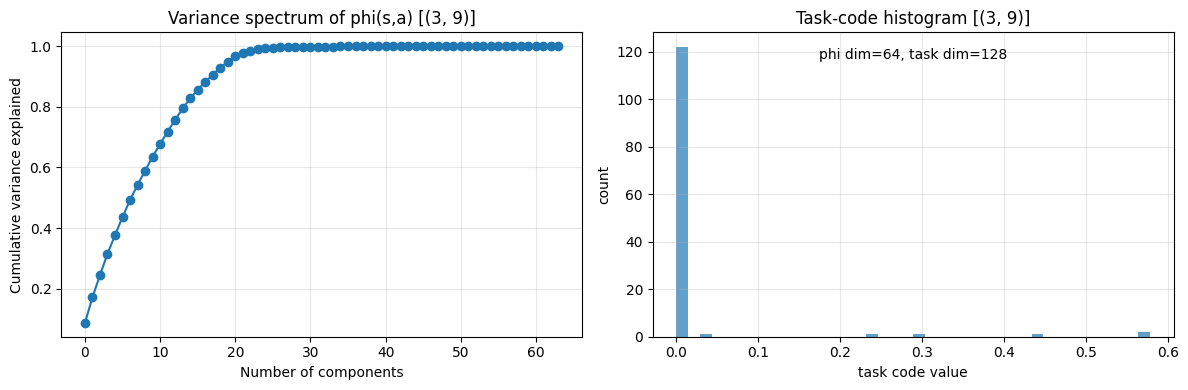


Goal embedding cosine similarity matrix:
     (9, 9)     (1, 1)     (7, 7)     (3, 5)     (3, 9)
  (9, 9)      1.000      0.896      0.889      0.292      0.008
  (1, 1)      0.896      1.000      0.850      0.287      0.056
  (7, 7)      0.889      0.850      1.000      0.382      0.103
  (3, 5)      0.292      0.287      0.382      1.000      0.865
  (3, 9)      0.008      0.056      0.103      0.865      1.000

Off-diagonal mean similarity: 0.463
Off-diagonal min similarity: 0.008
Off-diagonal max similarity: 0.896

----- seed=42, goal=(5, 5) -----

[DQN-mlp-raw-goal] step=   1000 | eps=0.988 | eval_return=-2.500 | eval_len=100.0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=False | td_updates_sa=False
[DQN-mlp-raw-goal] step=   2000 | eps=0.976 | eval_return=-1.250 | eval_len=100.0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=False | td_updates_sa=False


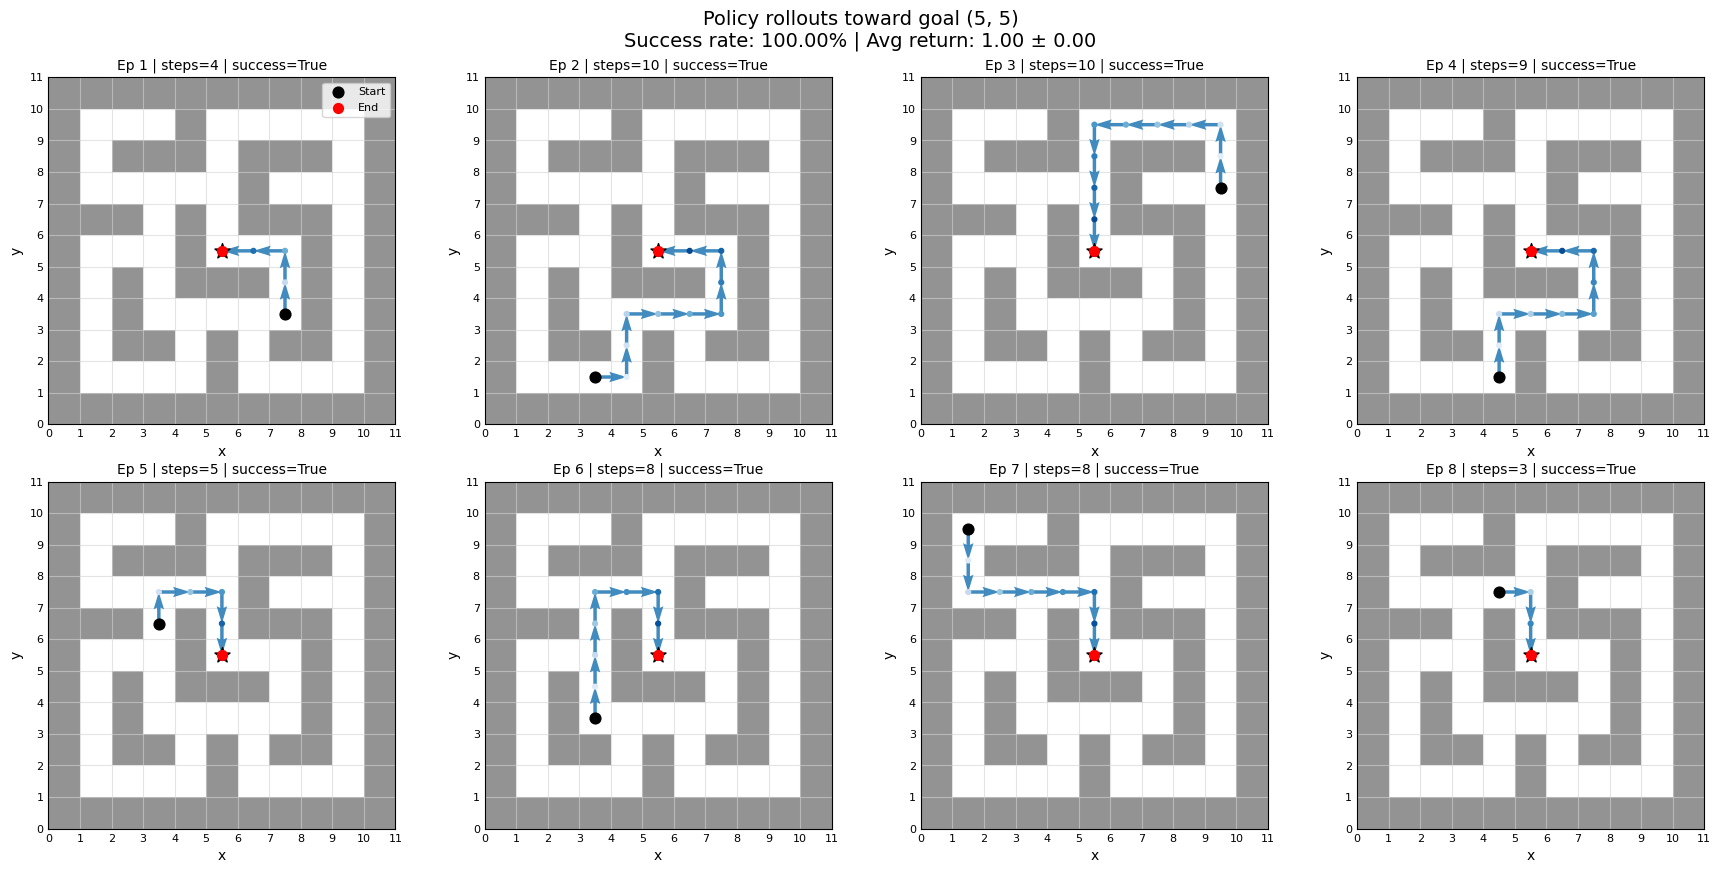

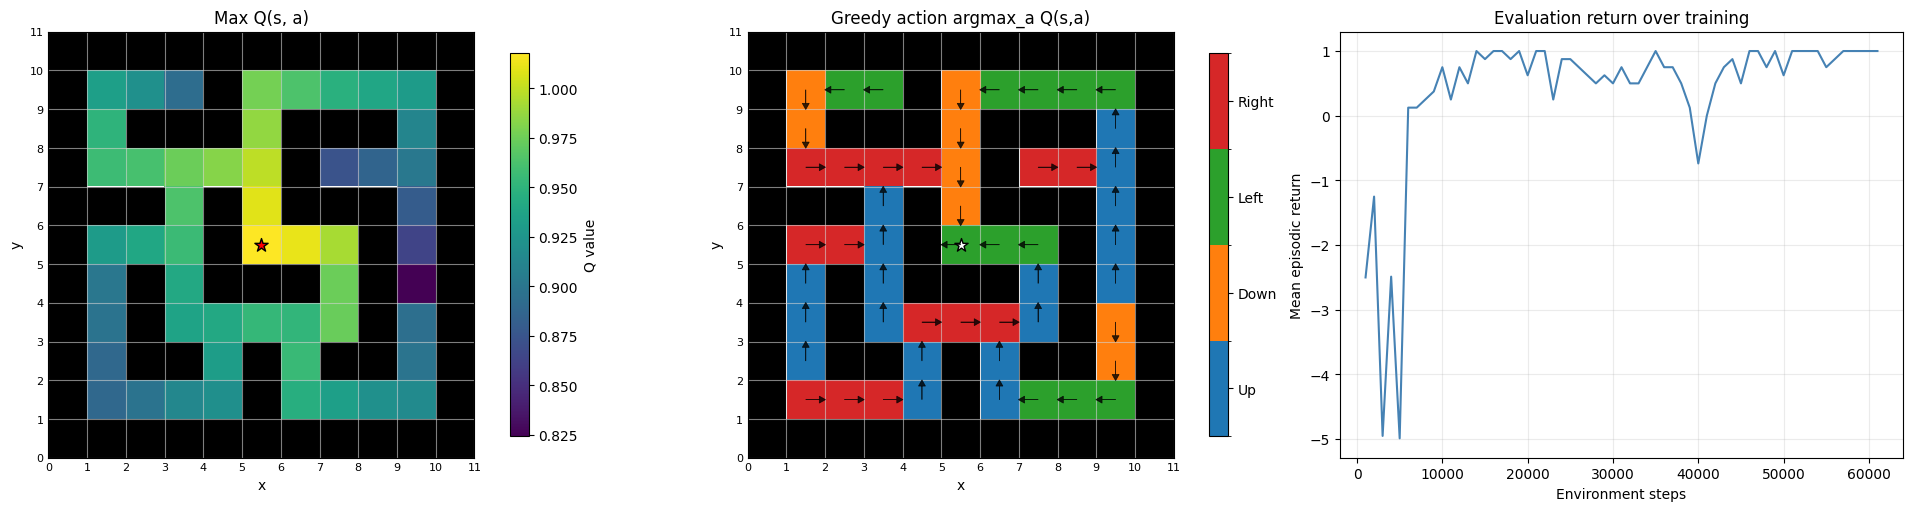

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 128)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [4.1902413 4.086147  3.8476024 3.6730187 3.6020699]
cumulative variance (first 5 dims): [0.08478265 0.16540527 0.23688933 0.30203345 0.3646852 ]
Skipping cosine histogram: phi dim = 64, goal/task dim = 128


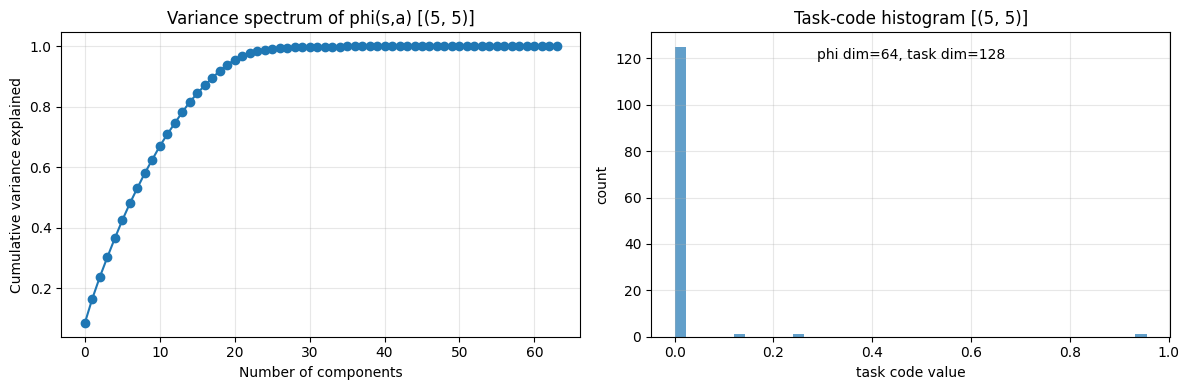


Goal embedding cosine similarity matrix:
     (9, 9)     (1, 1)     (7, 7)     (3, 5)     (3, 9)     (5, 5)
  (9, 9)      1.000      0.896      0.889      0.292      0.008      0.232
  (1, 1)      0.896      1.000      0.850      0.287      0.056      0.293
  (7, 7)      0.889      0.850      1.000      0.382      0.103      0.399
  (3, 5)      0.292      0.287      0.382      1.000      0.865      0.763
  (3, 9)      0.008      0.056      0.103      0.865      1.000      0.552
  (5, 5)      0.232      0.293      0.399      0.763      0.552      1.000

Off-diagonal mean similarity: 0.458
Off-diagonal min similarity: 0.008
Off-diagonal max similarity: 0.896

----- seed=42, goal=(3, 6) -----

[DQN-mlp-raw-goal] step=   1000 | eps=0.988 | eval_return=-0.875 | eval_len=63.1 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=False | td_updates_sa=False
[DQN-mlp-raw-goal] step=   2000 | eps=0.976 | eval_return=-3.737 | eval_len=100.

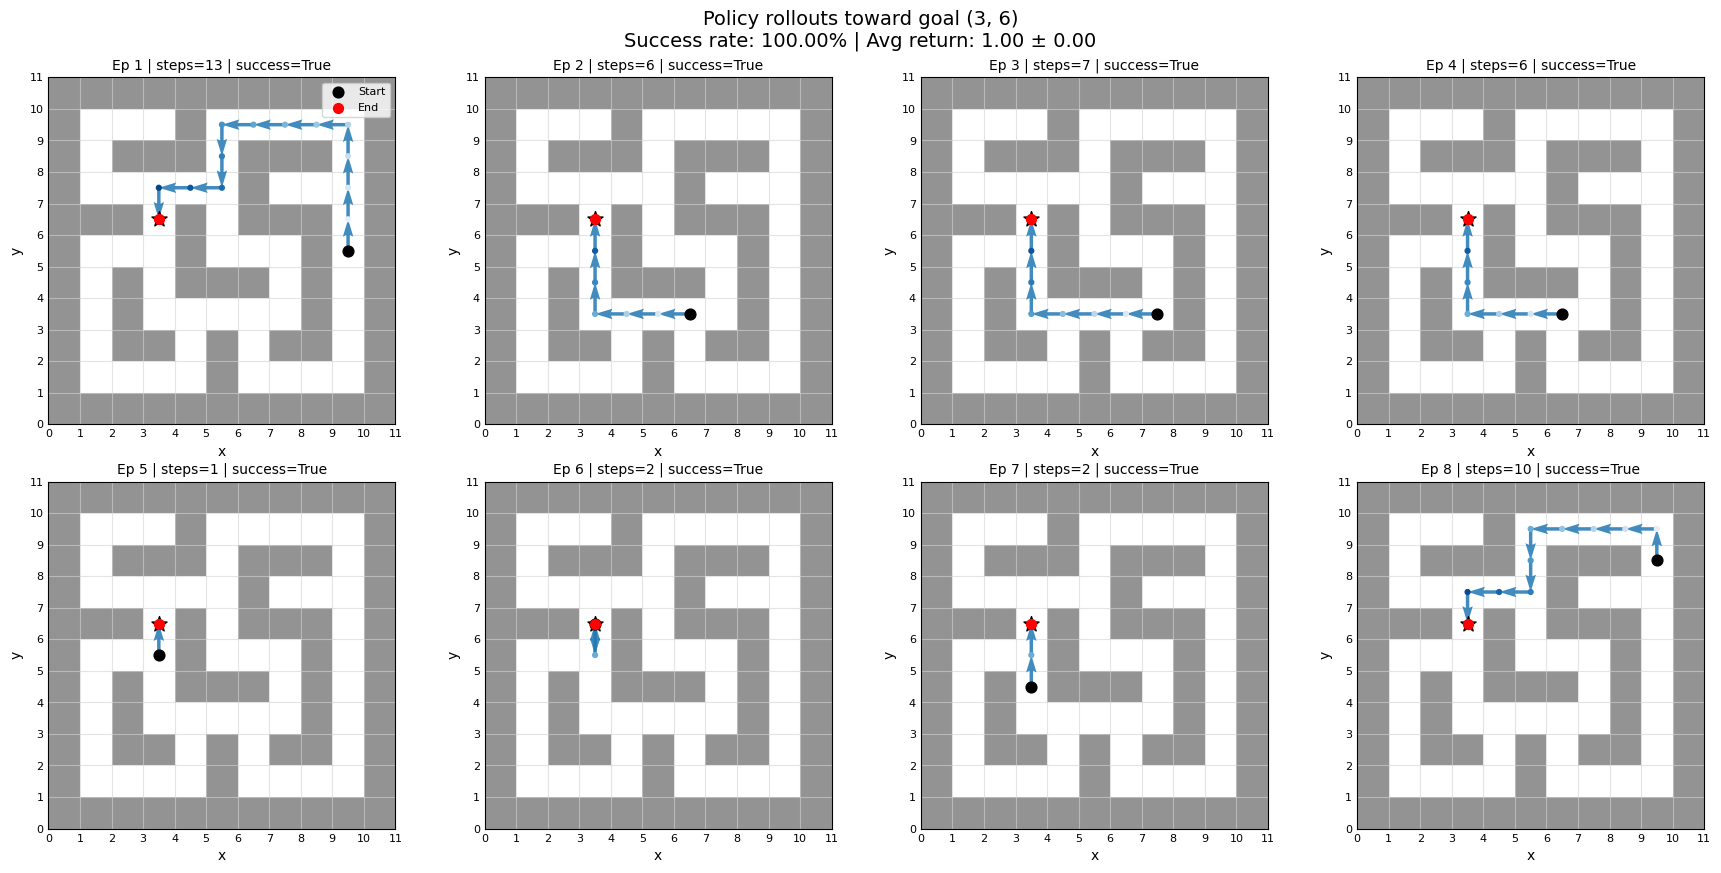

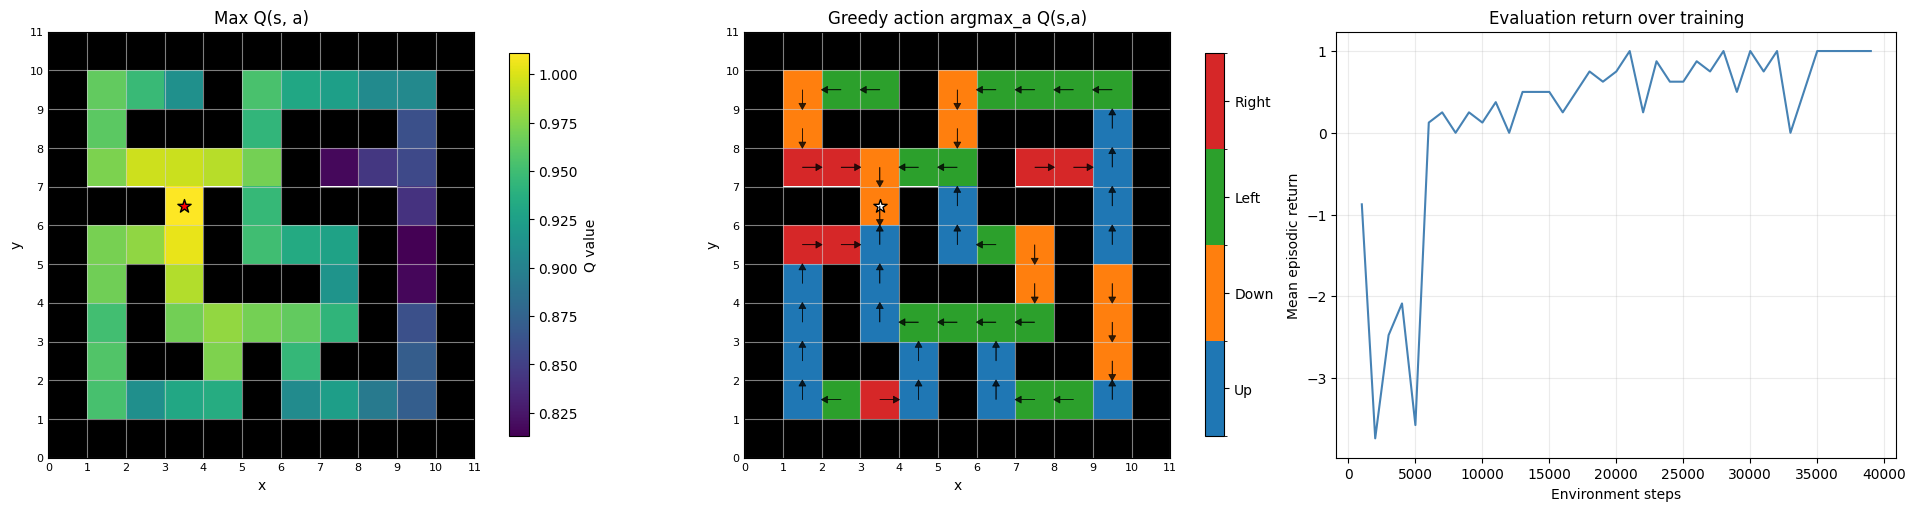

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 128)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [3.9457996 3.7202892 3.6283956 3.4873378 3.3820574]
cumulative variance (first 5 dims): [0.07515864 0.14197184 0.20552514 0.26423308 0.31944984]
Skipping cosine histogram: phi dim = 64, goal/task dim = 128


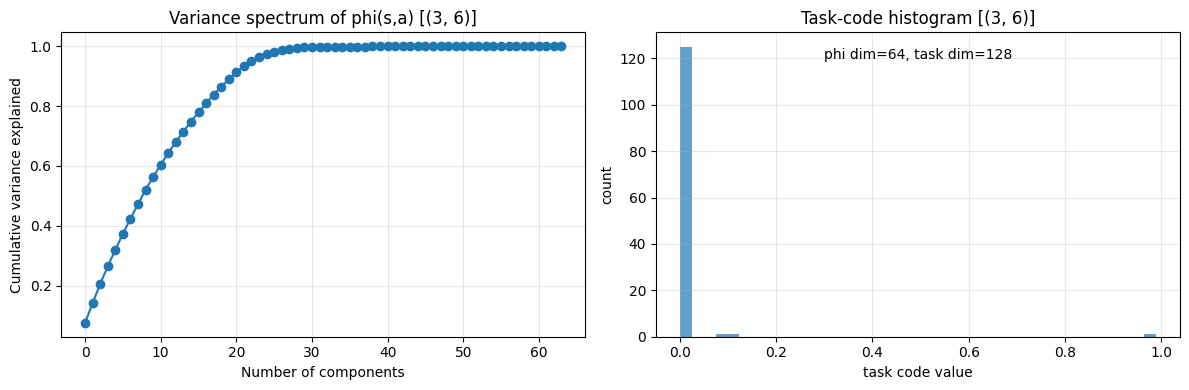


Goal embedding cosine similarity matrix:
     (9, 9)     (1, 1)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)
  (9, 9)      1.000      0.896      0.889      0.292      0.008      0.232      0.086
  (1, 1)      0.896      1.000      0.850      0.287      0.056      0.293      0.170
  (7, 7)      0.889      0.850      1.000      0.382      0.103      0.399      0.260
  (3, 5)      0.292      0.287      0.382      1.000      0.865      0.763      0.741
  (3, 9)      0.008      0.056      0.103      0.865      1.000      0.552      0.604
  (5, 5)      0.232      0.293      0.399      0.763      0.552      1.000      0.970
  (3, 6)      0.086      0.170      0.260      0.741      0.604      0.970      1.000

Off-diagonal mean similarity: 0.462
Off-diagonal min similarity: 0.008
Off-diagonal max similarity: 0.970

----- seed=42, goal=(9, 1) -----

[DQN-mlp-raw-goal] step=   1000 | eps=0.988 | eval_return=-4.912 | eval_len=100.0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | d

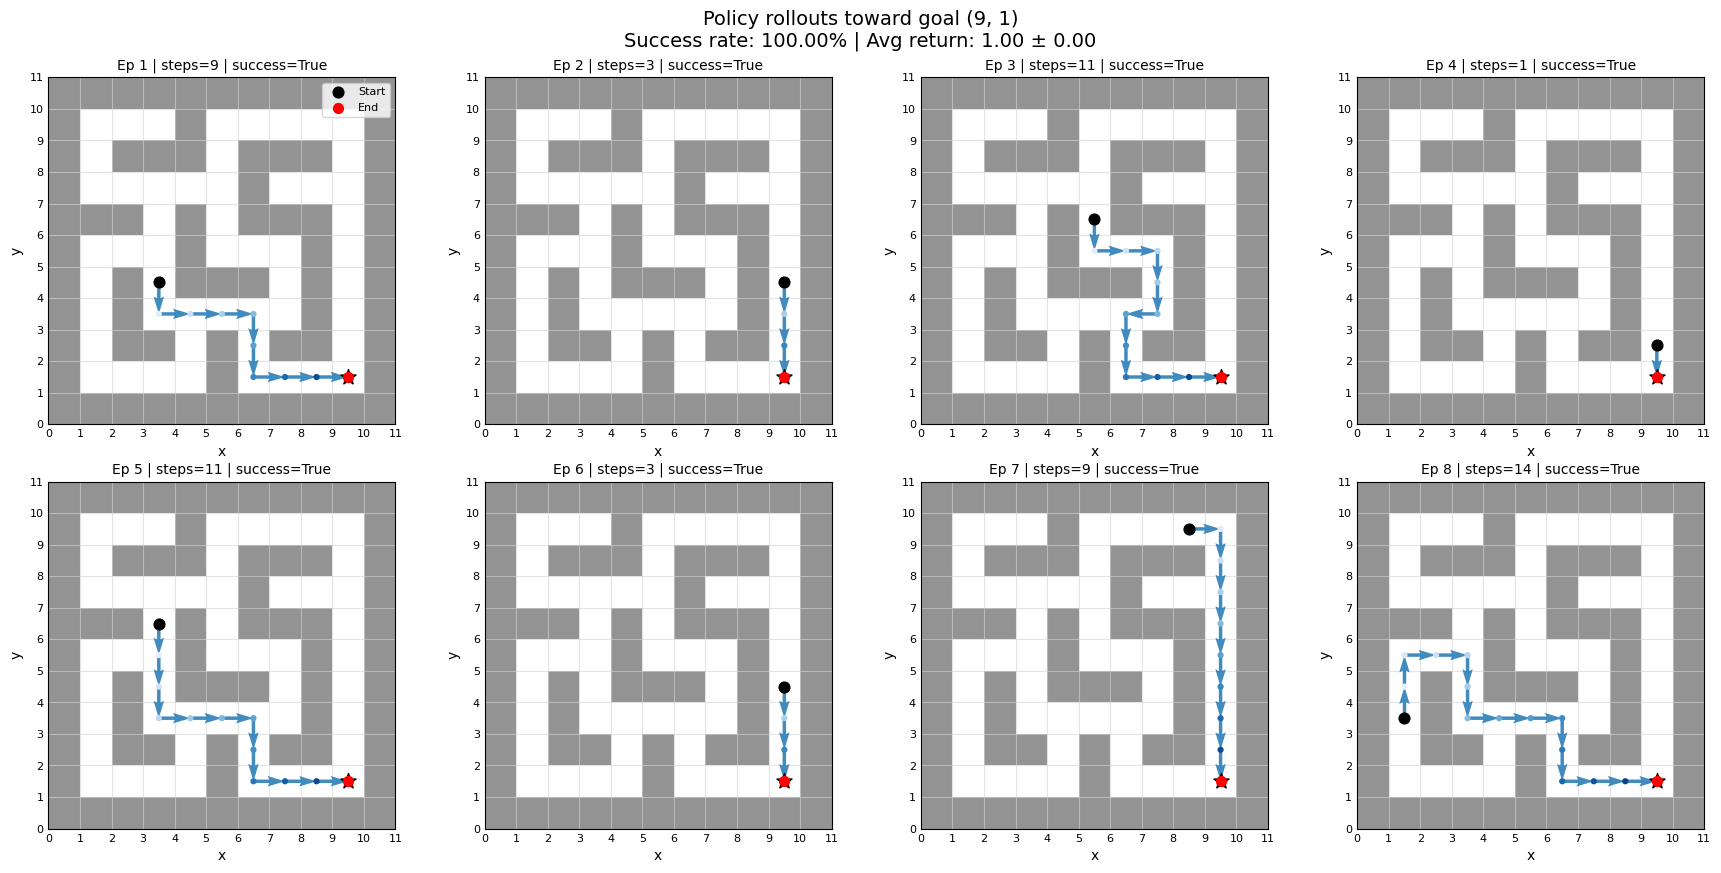

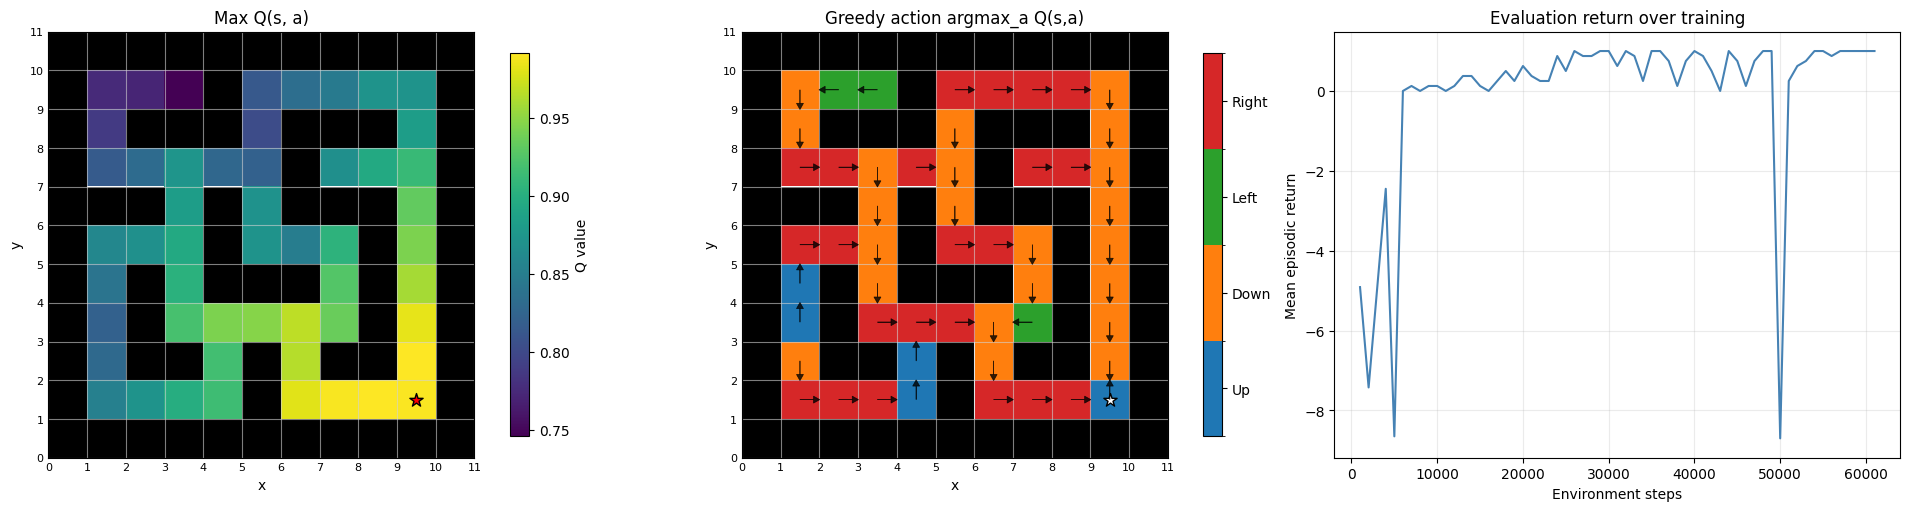

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 128)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [4.057479  3.8361712 3.6196094 3.6143277 3.495046 ]
cumulative variance (first 5 dims): [0.07945371 0.15047649 0.21370676 0.27675265 0.33570585]
Skipping cosine histogram: phi dim = 64, goal/task dim = 128


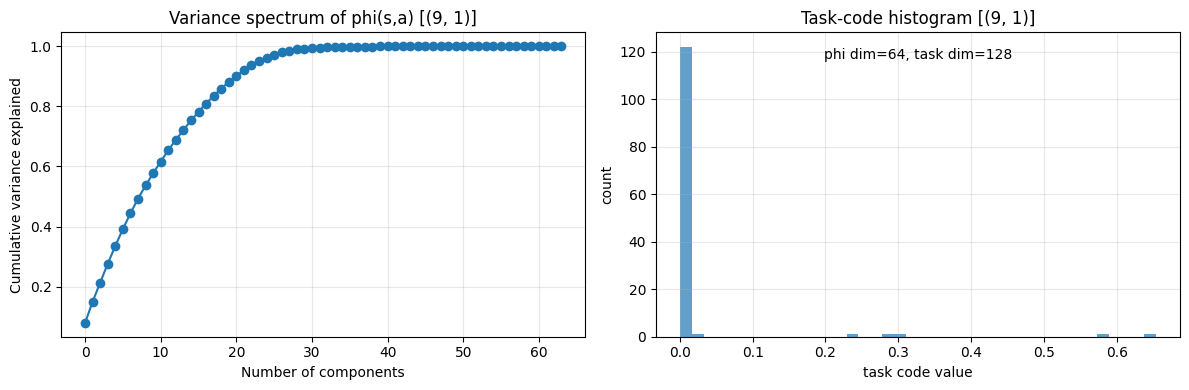


Goal embedding cosine similarity matrix:
     (9, 9)     (1, 1)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)     (9, 1)
  (9, 9)      1.000      0.896      0.889      0.292      0.008      0.232      0.086      0.209
  (1, 1)      0.896      1.000      0.850      0.287      0.056      0.293      0.170      0.209
  (7, 7)      0.889      0.850      1.000      0.382      0.103      0.399      0.260      0.258
  (3, 5)      0.292      0.287      0.382      1.000      0.865      0.763      0.741      0.271
  (3, 9)      0.008      0.056      0.103      0.865      1.000      0.552      0.604      0.165
  (5, 5)      0.232      0.293      0.399      0.763      0.552      1.000      0.970      0.423
  (3, 6)      0.086      0.170      0.260      0.741      0.604      0.970      1.000      0.303
  (9, 1)      0.209      0.209      0.258      0.271      0.165      0.423      0.303      1.000

Off-diagonal mean similarity: 0.412
Off-diagonal min similarity: 0.008
Off-diagonal max simi

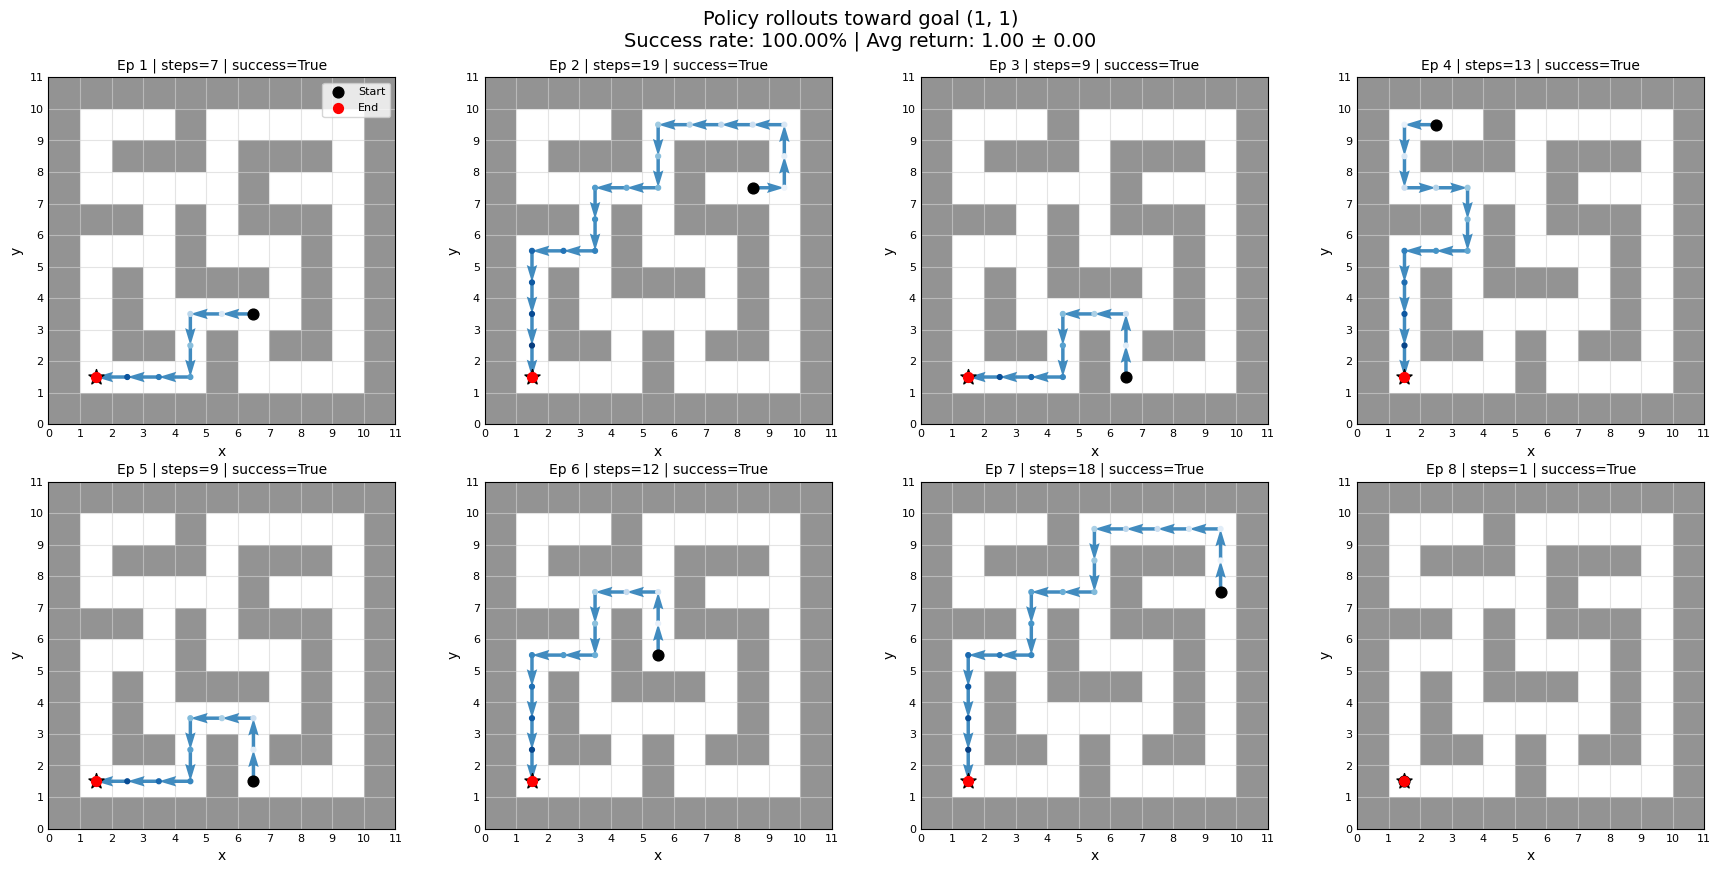

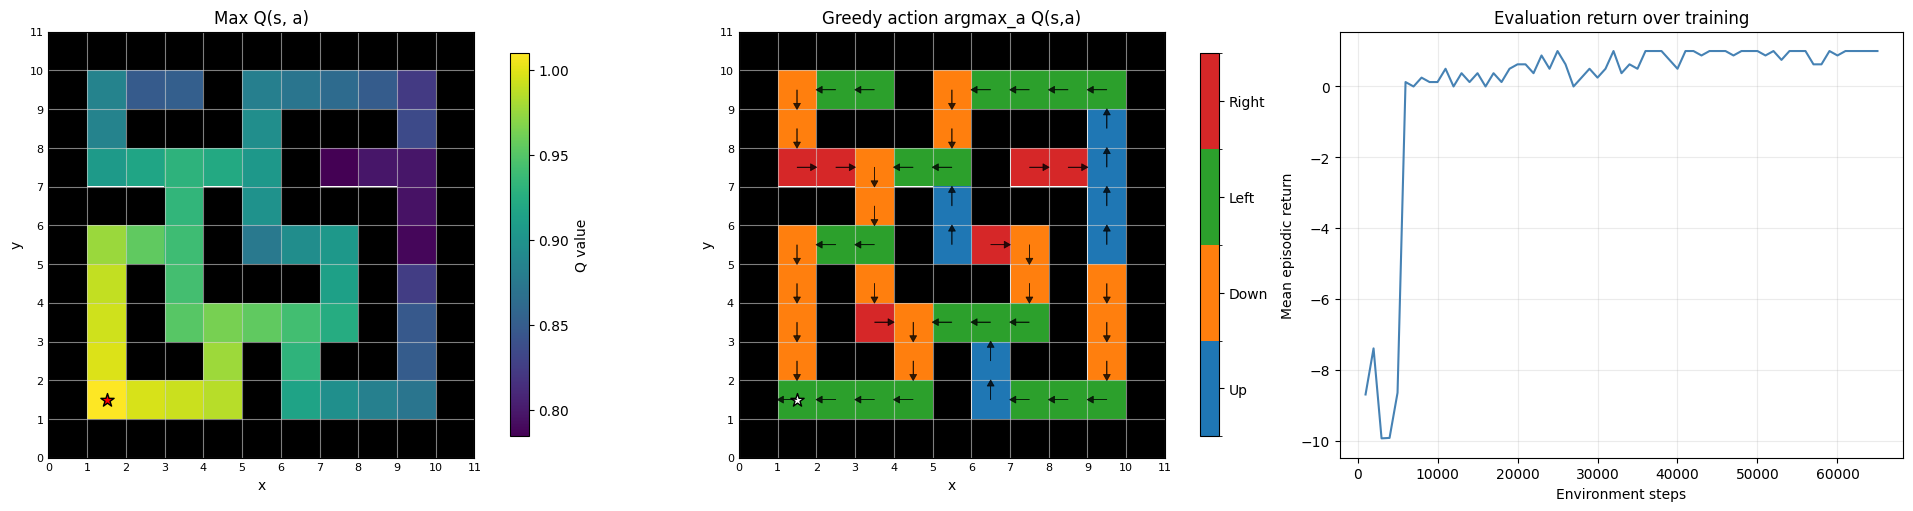

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 128)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [3.7597823 3.7049234 3.555973  3.352382  3.348597 ]
cumulative variance (first 5 dims): [0.06818414 0.13439304 0.19538532 0.24959351 0.30367938]
Skipping cosine histogram: phi dim = 64, goal/task dim = 128


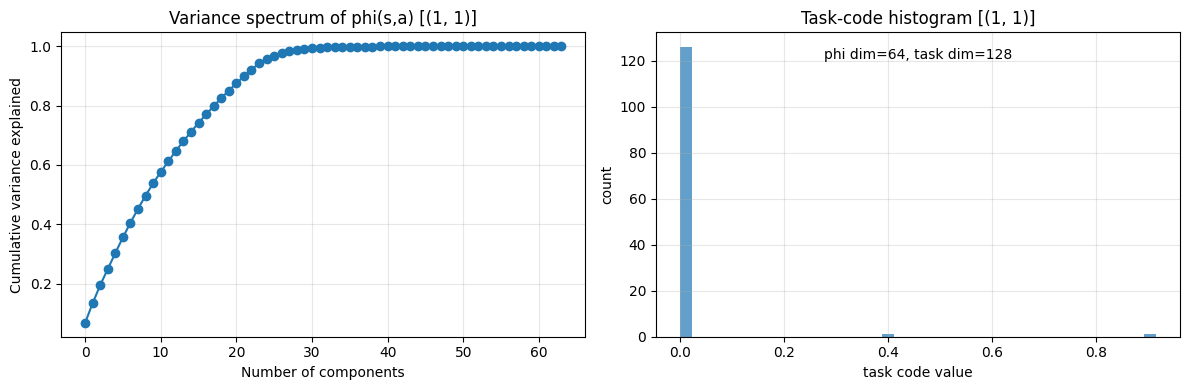


Goal embedding cosine similarity matrix:
     (9, 9)     (1, 1)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)     (9, 1)     (1, 1)
  (9, 9)      1.000      0.896      0.889      0.292      0.008      0.232      0.086      0.209      0.356
  (1, 1)      0.896      1.000      0.850      0.287      0.056      0.293      0.170      0.209      0.310
  (7, 7)      0.889      0.850      1.000      0.382      0.103      0.399      0.260      0.258      0.353
  (3, 5)      0.292      0.287      0.382      1.000      0.865      0.763      0.741      0.271      0.113
  (3, 9)      0.008      0.056      0.103      0.865      1.000      0.552      0.604      0.165      0.000
  (5, 5)      0.232      0.293      0.399      0.763      0.552      1.000      0.970      0.423      0.231
  (3, 6)      0.086      0.170      0.260      0.741      0.604      0.970      1.000      0.303      0.039
  (9, 1)      0.209      0.209      0.258      0.271      0.165      0.423      0.303      1.000      

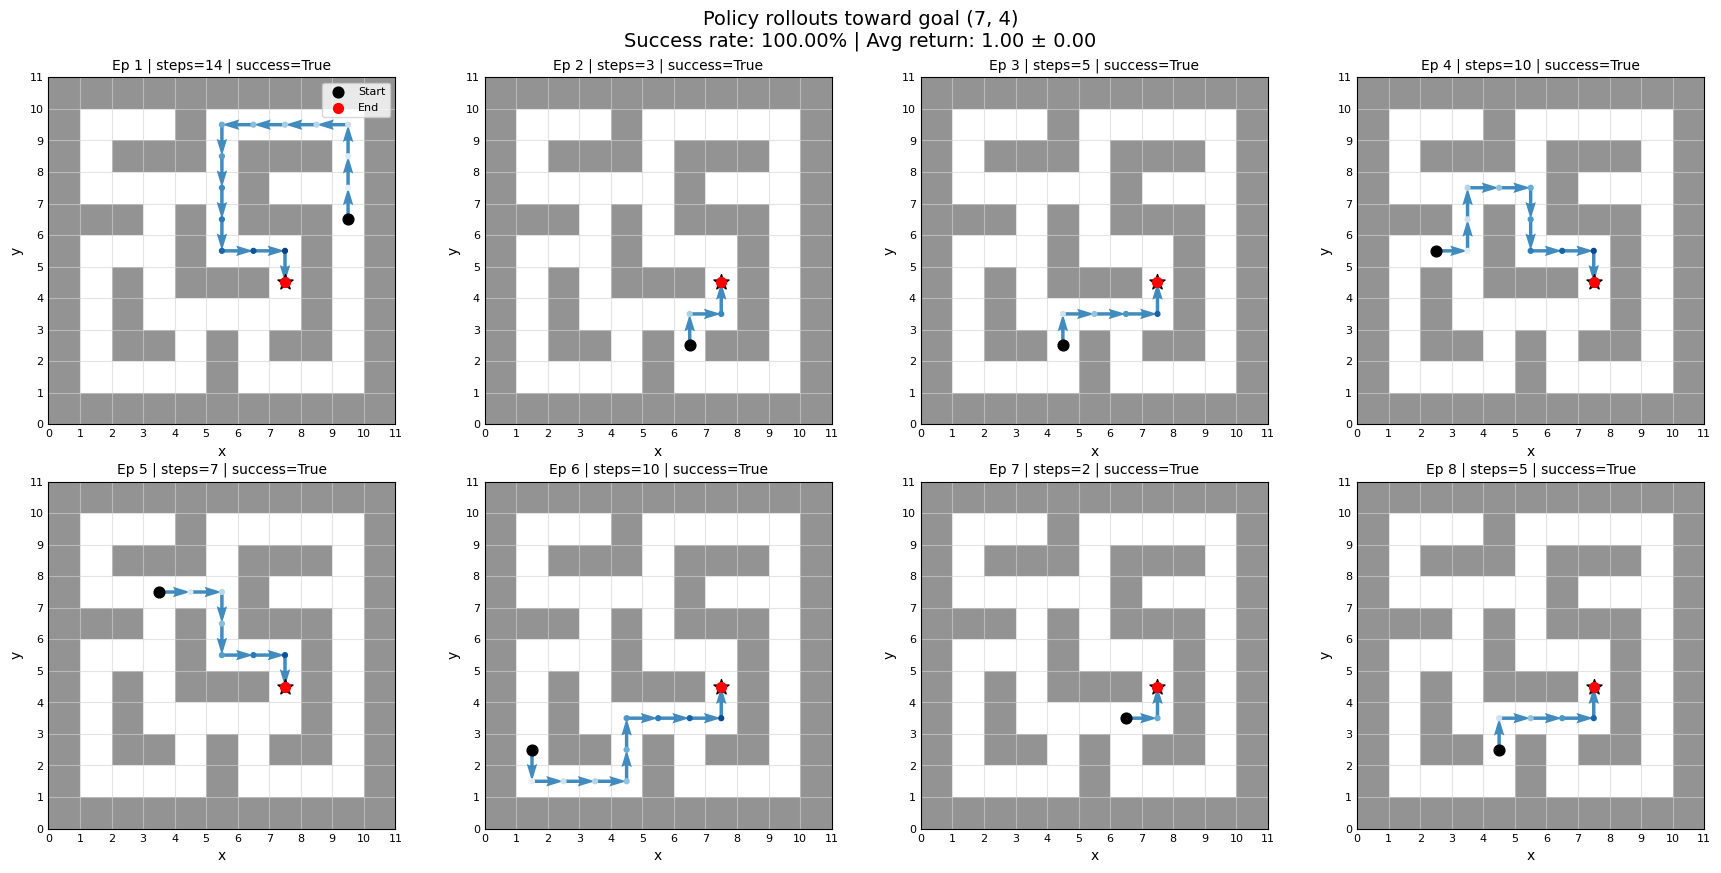

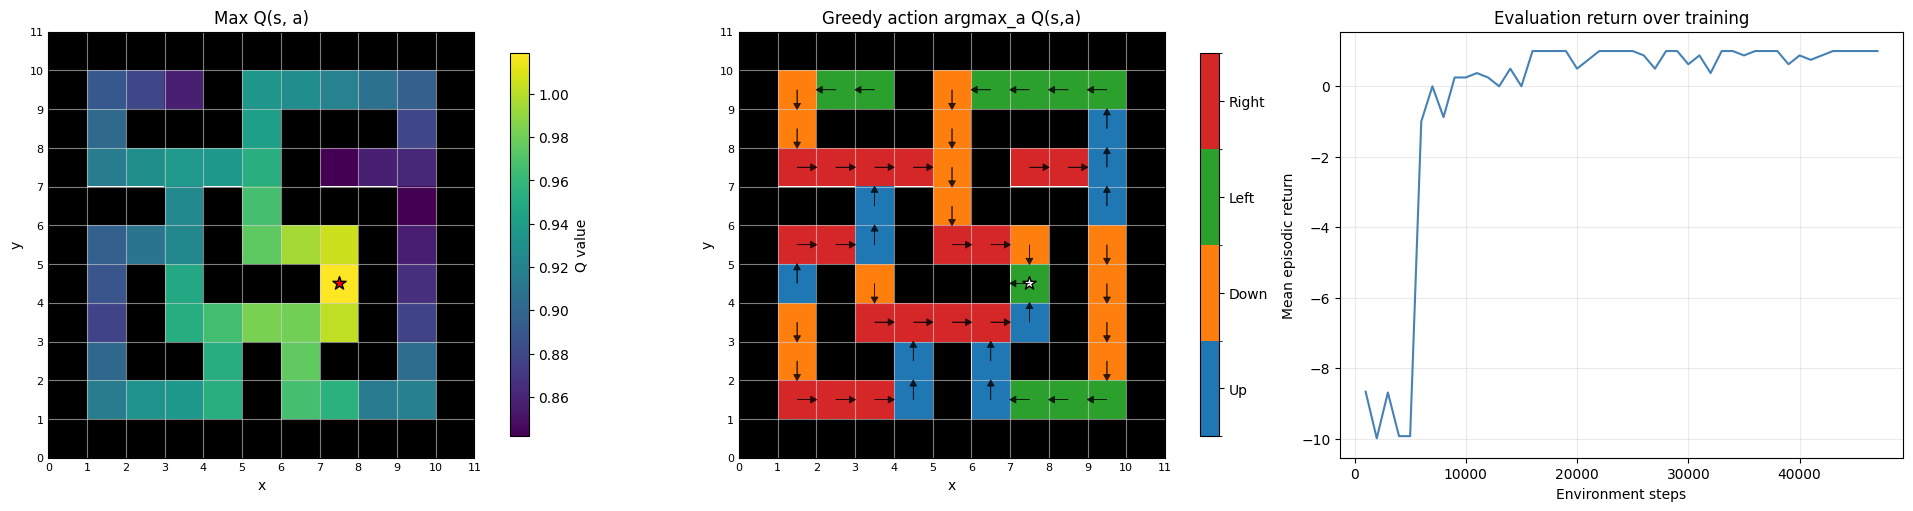

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 128)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [3.8123622 3.6464372 3.509979  3.446395  3.3297596]
cumulative variance (first 5 dims): [0.07015217 0.13433078 0.19379584 0.25112596 0.30464134]
Skipping cosine histogram: phi dim = 64, goal/task dim = 128


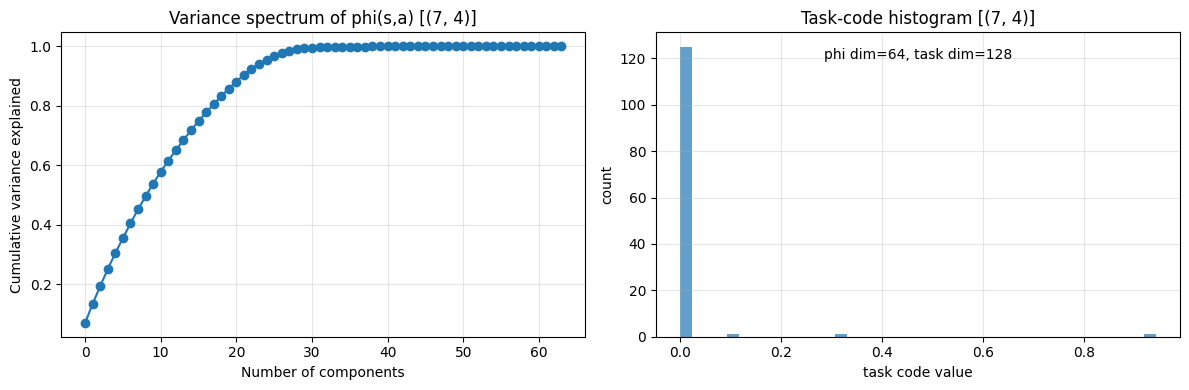


Goal embedding cosine similarity matrix:
     (9, 9)     (1, 1)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)     (9, 1)     (1, 1)     (7, 4)
  (9, 9)      1.000      0.896      0.889      0.292      0.008      0.232      0.086      0.209      0.356      0.276
  (1, 1)      0.896      1.000      0.850      0.287      0.056      0.293      0.170      0.209      0.310      0.240
  (7, 7)      0.889      0.850      1.000      0.382      0.103      0.399      0.260      0.258      0.353      0.274
  (3, 5)      0.292      0.287      0.382      1.000      0.865      0.763      0.741      0.271      0.113      0.088
  (3, 9)      0.008      0.056      0.103      0.865      1.000      0.552      0.604      0.165      0.000      0.000
  (5, 5)      0.232      0.293      0.399      0.763      0.552      1.000      0.970      0.423      0.231      0.212
  (3, 6)      0.086      0.170      0.260      0.741      0.604      0.970      1.000      0.303      0.039      0.030
  (9, 1)      

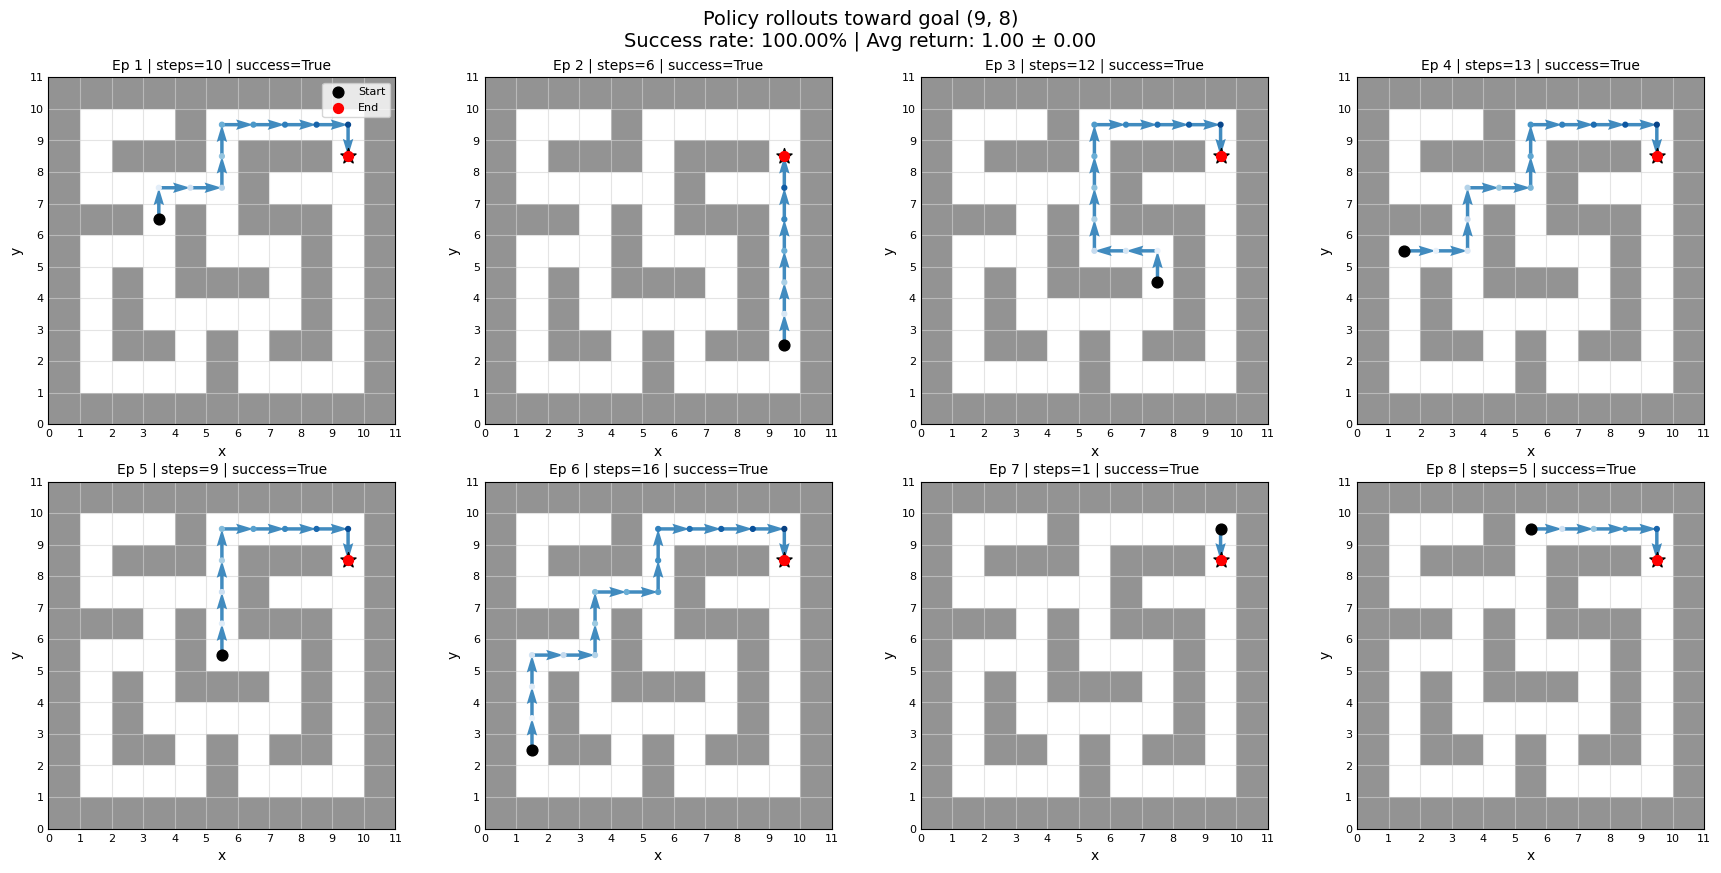

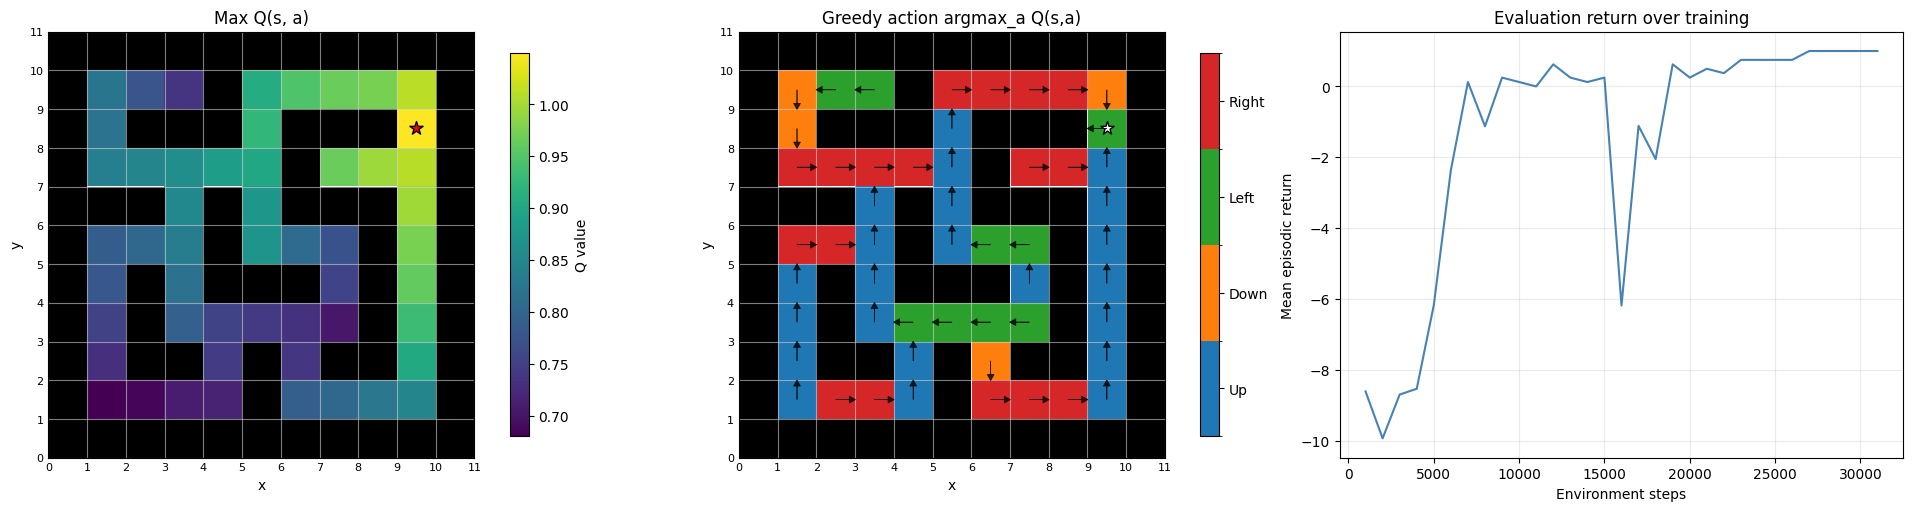

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 128)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [3.9675472 3.7038183 3.607393  3.4869807 3.3995001]
cumulative variance (first 5 dims): [0.07592951 0.14210021 0.20487039 0.26352003 0.31926382]
Skipping cosine histogram: phi dim = 64, goal/task dim = 128


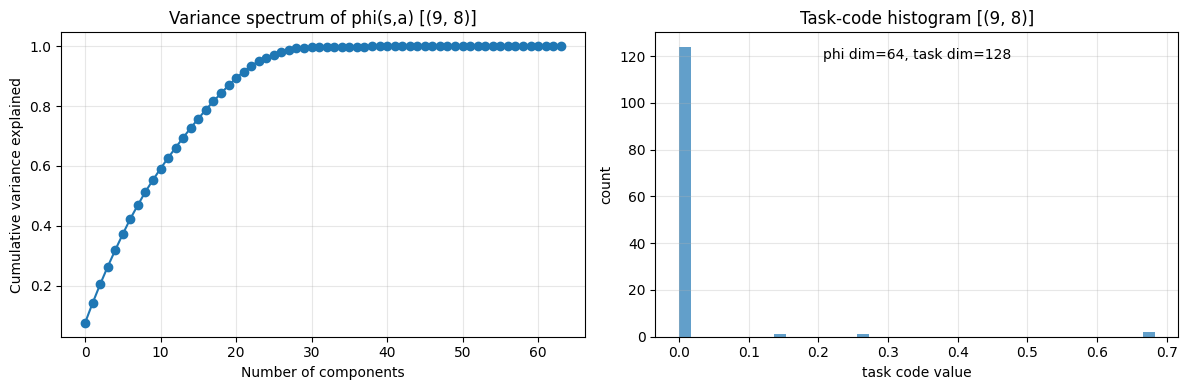


Goal embedding cosine similarity matrix:
     (9, 9)     (1, 1)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)     (9, 1)     (1, 1)     (7, 4)     (9, 8)
  (9, 9)      1.000      0.896      0.889      0.292      0.008      0.232      0.086      0.209      0.356      0.276      0.605
  (1, 1)      0.896      1.000      0.850      0.287      0.056      0.293      0.170      0.209      0.310      0.240      0.540
  (7, 7)      0.889      0.850      1.000      0.382      0.103      0.399      0.260      0.258      0.353      0.274      0.625
  (3, 5)      0.292      0.287      0.382      1.000      0.865      0.763      0.741      0.271      0.113      0.088      0.293
  (3, 9)      0.008      0.056      0.103      0.865      1.000      0.552      0.604      0.165      0.000      0.000      0.080
  (5, 5)      0.232      0.293      0.399      0.763      0.552      1.000      0.970      0.423      0.231      0.212      0.404
  (3, 6)      0.086      0.170      0.260      0.741    

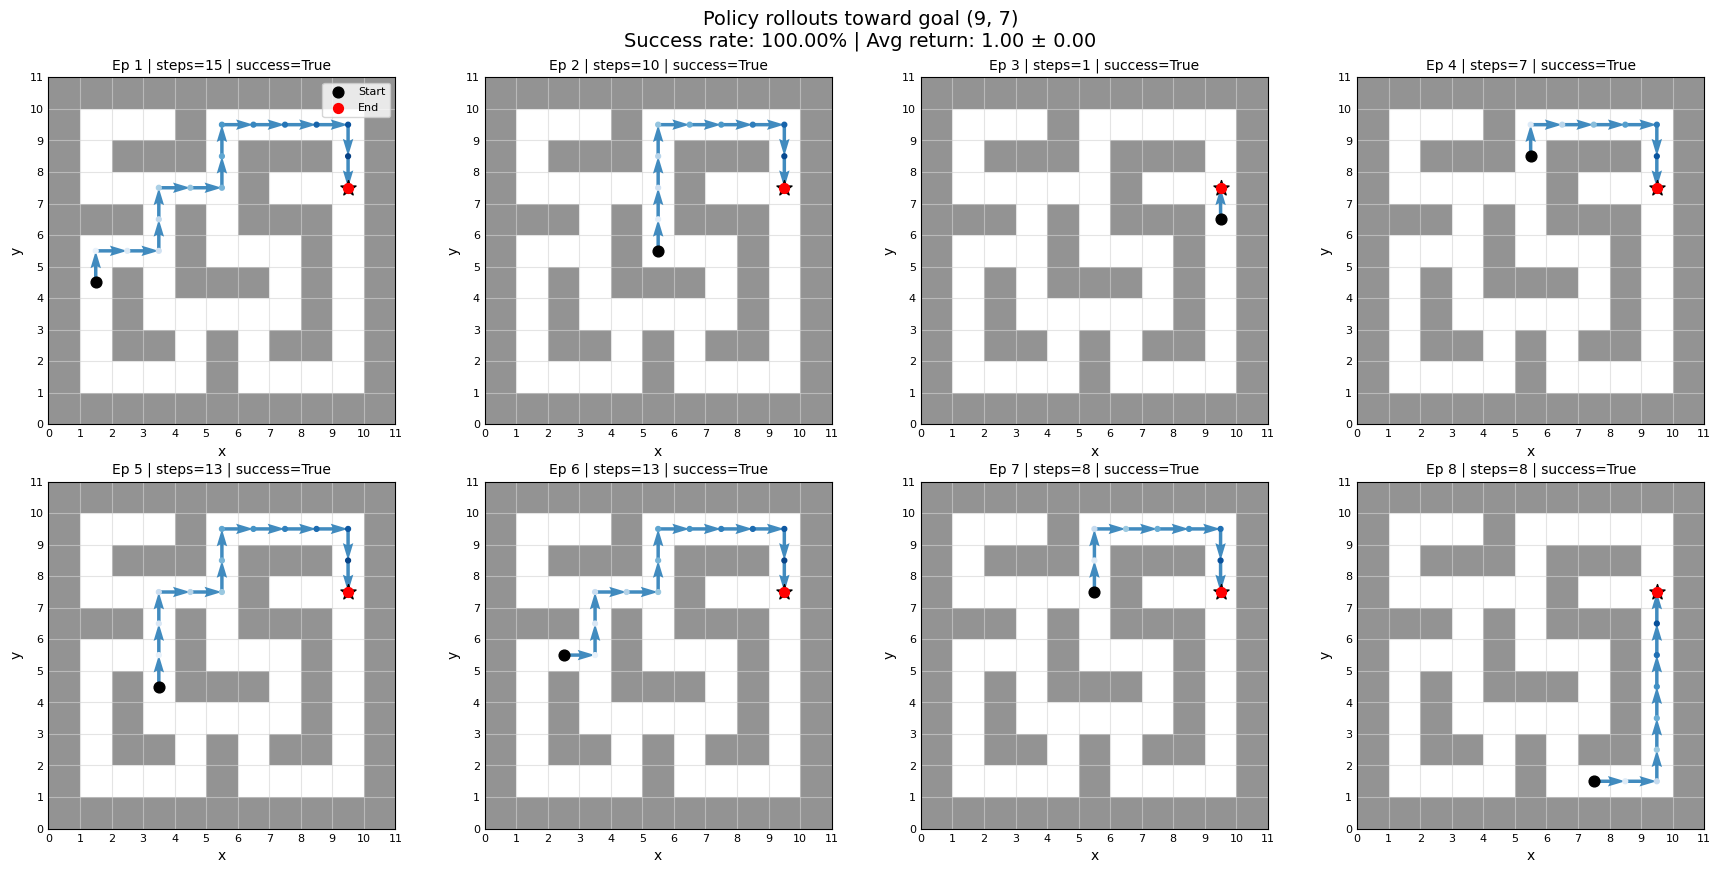

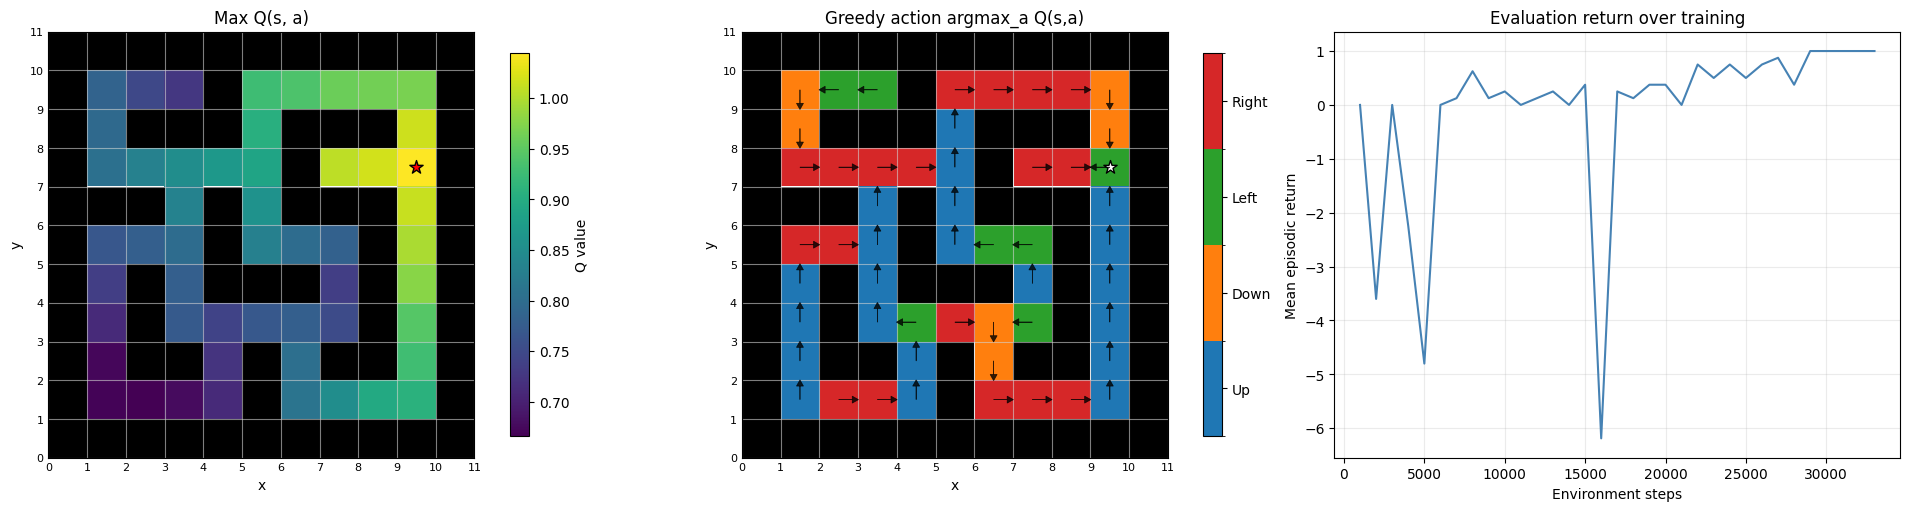

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 128)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [3.86578   3.682758  3.489112  3.4013925 3.337878 ]
cumulative variance (first 5 dims): [0.07227373 0.13786599 0.19674167 0.2526942  0.3065766 ]
Skipping cosine histogram: phi dim = 64, goal/task dim = 128


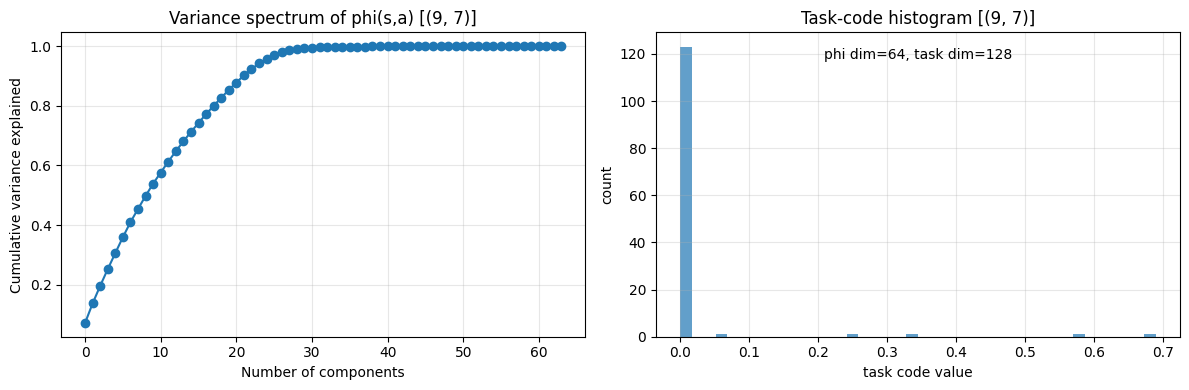


Goal embedding cosine similarity matrix:
     (9, 9)     (1, 1)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)     (9, 1)     (1, 1)     (7, 4)     (9, 8)     (9, 7)
  (9, 9)      1.000      0.896      0.889      0.292      0.008      0.232      0.086      0.209      0.356      0.276      0.605      0.612
  (1, 1)      0.896      1.000      0.850      0.287      0.056      0.293      0.170      0.209      0.310      0.240      0.540      0.565
  (7, 7)      0.889      0.850      1.000      0.382      0.103      0.399      0.260      0.258      0.353      0.274      0.625      0.668
  (3, 5)      0.292      0.287      0.382      1.000      0.865      0.763      0.741      0.271      0.113      0.088      0.293      0.442
  (3, 9)      0.008      0.056      0.103      0.865      1.000      0.552      0.604      0.165      0.000      0.000      0.080      0.198
  (5, 5)      0.232      0.293      0.399      0.763      0.552      1.000      0.970      0.423      0.231      0.212  

In [5]:
SEEDS = [42]
GOALS = [
    (9, 9), (1, 1), (7, 7), (3, 5), (3, 9), (5, 5),
    (3, 6), (9, 1), (1, 1), (7, 4), (9, 8), (9, 7)
]
BUFFER_CAPACITY = 100000
LR = float(1e-3)

sa_keywords_local = ["sa_encoder"]
goal_keywords_local = ["q_head"]

overall_results = {
    goal: {
        "eval_returns": [],
        "min_steps": [],
        "min_time": [],
        "task_embeddings": [],
        "sa_embeddings": [],
        "sa_fixed_probe_embeddings": [],
        "sa_batches_final": [],
    }
    for goal in GOALS
}

for seed in SEEDS:
    print(f"\n================ SEED {seed} ================\n")
    set_seed(seed)

    env_tmp = make_env(goal=GOALS[0])
    obs_dim = env_tmp.observation_space.shape[0]
    num_actions = env_tmp.action_space.n
    env_tmp.close()

    q_net_base = FactorisedDQN_QNetwork_MLPRawGoal(
        obs_dim=obs_dim,
        num_actions=num_actions,
        goal_dim=2,
        hidden_dim=128,
        rep_dim=64,
        q_hidden_dim=128,
        normalize_embeddings=True,
    ).to(DEVICE)

    q_target_base = FactorisedDQN_QNetwork_MLPRawGoal(
        obs_dim=obs_dim,
        num_actions=num_actions,
        goal_dim=2,
        hidden_dim=128,
        rep_dim=64,
        q_hidden_dim=128,
        normalize_embeddings=True,
    ).to(DEVICE)

    next_state_encoder = NextStateEncoder(
        obs_dim=obs_dim,
        hidden_dim=128,
        rep_dim=64,
    ).to(DEVICE)

    seed_task_embedding_memory = []
    seen_goal_labels = []
    weight_history = []
    prev_q_net = None
    prev_q_target = None

    for goal_idx, goal in enumerate(GOALS):
        print(f"\n----- seed={seed}, goal={goal} -----\n")

        if goal_idx == 0:
            q_net = deepcopy(q_net_base)
            q_target = deepcopy(q_target_base)
            q_target.load_state_dict(q_net.state_dict())

            for p in q_net.parameters():
                p.requires_grad_(True)

            freeze_sa_encoder = False
            epsilon_reduction = False

        else:
            if prev_q_net is None or prev_q_target is None:
                raise ValueError("Previous Q-networks are not available for transfer learning.")

            q_net = deepcopy(prev_q_net)
            q_target = deepcopy(prev_q_target)
            q_target.load_state_dict(q_net.state_dict())

            for p in q_net.sa_encoder.parameters():
                p.requires_grad_(True)
            for p in q_target.sa_encoder.parameters():
                p.requires_grad_(True)

            for p in q_net.q_head.parameters():
                p.requires_grad_(True)

            freeze_sa_encoder = False
            epsilon_reduction = False

        weight_history.append(
            collect_weight_snapshot(
                qnet=q_net,
                goal_label=goal,
                stage_label=f"goal_{goal_idx}_before_train_{goal}",
                sa_keywords_local=sa_keywords_local,
                goal_keywords_local=goal_keywords_local,
                max_samples_per_group=40000,
            )
        )

        (
            q_network,
            q_target_network,
            next_state_encoder,
            eval_returns,
            min_steps,
            min_time,
            task_embedding,
            sa_embedding_mean,
            sa_embedding_fixed,
            sa_batch_final,
            buffer,
        ) = dqn_train_mlp_raw_goal_online(
            seed=seed,
            q_network=q_net,
            q_target_network=q_target,
            env=make_env(goal=goal),
            buffer_capacity=BUFFER_CAPACITY,
            obs_dim=obs_dim,
            device=DEVICE,
            total_steps=100000,
            warmup_steps=5000,
            batch_size=256,
            gamma=0.99,
            tau=0.005,
            eps_start=1.0,
            eps_end=0.05,
            eps_decay_steps=80000,
            train_freq=4,
            goal=goal,
            td_steps=1,
            make_env=make_env,
            epsilon_reduction=epsilon_reduction,
            eps_start_transfer=0.2,
            eps_end_transfer=0.05,
            eps_decay_steps_transfer=20000,
            lr_sa=LR,
            lr_ns=LR,
            lr_td=LR,
            next_state_encoder=next_state_encoder,
            temperature=0.05,
            contrastive_reg_coef=0.0,
            sigreg_coef=0.01,
            dyn_coef=1.0,
            freeze_sa_encoder=freeze_sa_encoder,
            td_updates_sa_encoder=False,   # keep TD from reshaping phi if you want cleaner separation
        )

        weight_history.append(
            collect_weight_snapshot(
                qnet=q_network,
                goal_label=goal,
                stage_label=f"goal_{goal_idx}_after_train_{goal}",
                sa_keywords_local=sa_keywords_local,
                goal_keywords_local=goal_keywords_local,
                max_samples_per_group=40000,
            )
        )

        visualise_q_table(
            goal,
            q_network,
            eval_returns=eval_returns,
            device=DEVICE,
            make_env=make_env,
        )

        visualise_embeddings(
            goal=goal,
            q_network=q_network,
            device=DEVICE,
            make_env=make_env,
            action_mode="all_discrete",
        )

        seed_task_embedding_memory.append(task_embedding)
        seen_goal_labels.append(str(goal))
        print_goal_embedding_similarity(
            seed_task_embedding_memory,
            goal_labels=seen_goal_labels,
        )

        prev_q_net = deepcopy(q_network)
        prev_q_target = deepcopy(q_target_network)

        overall_results[goal]["eval_returns"].append(eval_returns)
        overall_results[goal]["min_steps"].append(min_steps)
        overall_results[goal]["min_time"].append(min_time)
        overall_results[goal]["task_embeddings"].append(task_embedding)
        overall_results[goal]["sa_embeddings"].append(sa_embedding_mean)
        overall_results[goal]["sa_fixed_probe_embeddings"].append(sa_embedding_fixed)
        overall_results[goal]["sa_batches_final"].append(sa_batch_final)

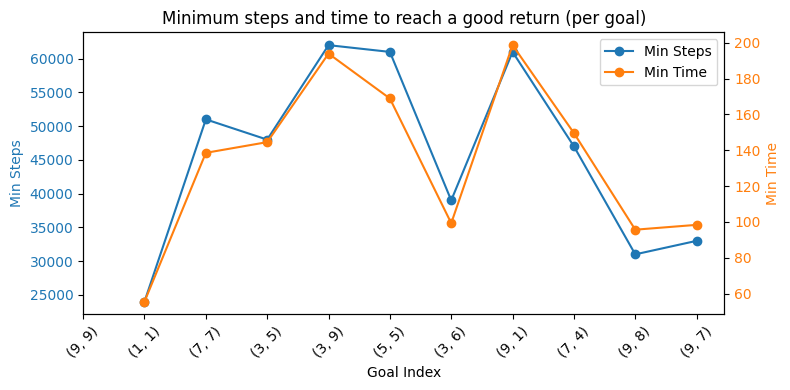

In [6]:
goals = list(overall_results.keys())

min_steps_per_goal = []
min_time_per_goal = []
used_goals = []

for goal in goals:
    steps_raw = overall_results[goal]["min_steps"]
    time_raw  = overall_results[goal]["min_time"]

    steps_arr = np.array(steps_raw).flatten()
    time_arr  = np.array(time_raw).flatten()

    # Skip goals with no data
    if steps_arr.size == 0 or time_arr.size == 0:
        print(f"[WARN] Skipping goal {goal}: empty min_steps or min_time")
        continue

    min_steps_per_goal.append(steps_arr.min())
    min_time_per_goal.append(time_arr.min())
    used_goals.append(goal)

if not min_steps_per_goal:
    raise ValueError("No goals with non-empty min_steps/min_time found.")

x = np.arange(len(used_goals))

fig, ax1 = plt.subplots(figsize=(8,4))

ax1.set_title("Minimum steps and time to reach a good return (per goal)")

# Left y-axis: min steps
line1 = ax1.plot(
    x, min_steps_per_goal,
    label="Min Steps",
    color="tab:blue",
    marker="o",
)
ax1.set_xlabel("Goal Index")
ax1.set_ylabel("Min Steps", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

# Right y-axis: min time
ax2 = ax1.twinx()
line2 = ax2.plot(
    x, min_time_per_goal,
    label="Min Time",
    color="tab:orange",
    marker="o",
)
ax2.set_ylabel("Min Time", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

# Label x-axis with actual goal IDs
ax1.set_xticks(x)
ax1.set_xticklabels([str(g) for g in used_goals], rotation=45)

# Combined legend
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="best")

fig.tight_layout()
plt.show()

## Backward Compatibility test (or new goal test)

Do not retrain anything, just give the task embedding, and check whether the sa encoder can give good Q functions still. The task embedding must be previously learned.

In [7]:
GOALS = [(9, 9), (9,8), (9,7)]

drift = compute_embedding_drift(overall_results, q_network, DEVICE)
for goal, cos in drift.items():
    print(goal, "cos(old, final) =", cos)

for goal in GOALS:

    if goal not in overall_results:
        task_embedding = extract_task_code_from_mlp(
            q_network=q_network,
            goal_raw=np.array(goal, dtype=np.float32),
            device=DEVICE,
            phi_probe=None,
        )
    else:
        task_embedding = overall_results[goal]["task_embeddings"]
    visualise_q_table(goal, q_network, eval_returns=None, task_embedding=task_embedding, device=DEVICE, make_env=make_env)
    visualise_embeddings(goal, q_network, device=DEVICE, make_env=make_env)

(9, 9) cos(old, final) = 0.6651858687400818
(1, 1) cos(old, final) = 0.5531827807426453
(7, 7) cos(old, final) = 0.7141404151916504
(3, 5) cos(old, final) = 0.39839664101600647
(3, 9) cos(old, final) = 0.0
(5, 5) cos(old, final) = 0.5802226066589355
(3, 6) cos(old, final) = 0.191360205411911
(9, 1) cos(old, final) = 0.8787552118301392
(7, 4) cos(old, final) = 0.8076959848403931
(9, 8) cos(old, final) = 0.9760192632675171
(9, 7) cos(old, final) = 1.0


/Users/juntan/Documents/MSc_Applied_Machine_Learning/Repos/Dissertation/MSc_Dissertation/src/visualisations.py:1203: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:256.)
  task_embedding = torch.tensor(task_embedding, dtype=torch.float32, device=device)


AttributeError: 'FactorisedDQN_QNetwork_MLPRawGoal' object has no attribute 'q_val_for_argmax_action_from_embedding'

## HTML visualisation

In [ ]:
for goal, data in overall_results.items():
    print(goal)
    print("task_embeddings:", len(data.get("task_embeddings", [])))
    print("sa_fixed_probe_embeddings:", len(data.get("sa_fixed_probe_embeddings", [])))
    print("sa_batches_final:", len(data.get("sa_batches_final", [])))

dashboard = plot_full_embedding_dashboard_2d_html(
    overall_results=overall_results,
    qnet=q_network,
    mode="all",
    save_html="plots/full_embedding_dashboard_maze.html",
    weights_his=weight_history,
)

print(dashboard["save_html"])
print(dashboard["isotropy_metrics"])